# SNe MCMC

## Observable: Distance modulus $\mu$ for multiple redshift bins from SNe (LSST or DES).

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
#load modules
import numpy as np, sys, os
sys.path.append('modules/')
import sne_cmb_fisher_tools, misc
from astropy import constants as const
from astropy import units as u
from astropy import coordinates as coord
from astropy.cosmology import FlatLambdaCDM


from pylab import *

In [3]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'

In [4]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)

In [6]:
run_chains = True #False ##True
if run_chains:

    import cobaya
    import getdist
    from getdist import plots, MCSamples

    #some variables
    #which_sne_data = 'lsst_binned'
    #which_sne_data = 'lsst_unbinned'
    #which_sne_data = 'des'
    which_sne_data = 'des_cobaya'
    #which_sne_data = 'test'
    unbinned_sne_sim_no = 1

    transform_fisher = False

    #get sne details
    print('\nget sne details')
    sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = True)
    sne_zarr = sne_details_dic['sne_zarr']
    sne_muarr = sne_details_dic['sne_muarr']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_muerr_sys = sne_details_dic['sne_muerr_sys']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
    sne_params = sne_details_dic['sne_params']
    sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']

    #params
    paramfile = 'data/params.ini'
    baselinecosmo = 'Flatw0waCDM'


    #get the params as dict
    print('\nget the params as dict')
    param_dict = misc.get_param_dict(paramfile)
    param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
    ##print(param_dict.keys())
    sys.exit()
    
    if (0):
        from astropy import constants
        cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)

        z = 0.7
        print( cosmo.comoving_distance(z)/(1+z) )
        print( constants.c.to('km/s')/cosmo.H(z) )
        print( cosmo.comoving_volume(z) )
        print( (z * constants.c.to('km/s')/cosmo.H(z) * cosmo.comoving_distance(z)**2. )**(1/3.) )

    data = sne_details_dic['sne_muarr']
    sne_zarr = sne_details_dic['sne_zarr']

    cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)
    ideal_data = np.asarray( [cosmo.distmod(z).value for z in sne_zarr] )

    cov = sne_details_dic['sne_tot_cov'][1]
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']## * 20.
    cov = np.diag( sne_muerr_stat )**2.
    ###print(cov); sys.exit()
    ##mock_data = np.asarray( [ (np.random.standard_normal(1) * err + mean)[0] for (mean, err) in zip(ideal_data, sne_muerr_stat) ] )
    mock_data = np.copy( ideal_data )


    clf()
    plot( ideal_data, ideal_data, 'k-')
    plot(data, ideal_data, 'ro', ls = 'None')
    errorbar(mock_data, ideal_data, yerr = sne_muerr_stat, marker = '.', color = 'black', capsize = 1., ls = 'None')
    xlim(36., 45.); ylim(36., 45.)
    xlabel(r'True distane modulus')
    ylabel(r'Observed distane modulus')
    grid(True, which = 'both', axis = 'both', lw = 0.2, alpha = 0.2)
    show()


    #data = sne_details_dic['sne_muarr']
    data = np.copy( mock_data )
    #print(sne_details_dic['sne_muarr'])
    #print(data); sys.exit()
    sne_zarr = sne_details_dic['sne_zarr']

    #cov = sne_details_dic['sne_tot_cov'][1]
    #cov = sne_details_dic['sne_stat_cov']
    cov_inv = np.linalg.inv(cov)

    import copy
    def get_log_likelihood(model):
        diff = data - model
        logl = -0.5 * np.asarray( np.dot(diff.T, np.dot( cov_inv, diff ))).squeeze()
        return logl

    def get_sne_dist_mod_likelihood(**param_values):
        param_values = [param_values[p] for p in param_names]
        param_dict_sampler = copy.deepcopy( param_dict )
        ###print(param_dict_sampler.keys(), param_names); sys.exit()
        for pcntr, ppp in enumerate( param_names ):
            param_dict_sampler[ppp] = param_values[pcntr]
        cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict_sampler, baselinecosmo = baselinecosmo)
        model = np.asarray( [cosmo.distmod(z).value for z in sne_zarr] )
        res = get_log_likelihood(model)
        return res

    # define likelihood function
    input_info = {}
    input_info["params"] = dict([
                ("omch2", {
                    "prior": {"min": 0.001, "max": 0.99},
                    "ref": {"dist": "norm", "loc": 0.12, "scale": 0.001},
                    "proposal": 0.0005,
                    "drop": False, 
                    "latex": r"\Omega_\mathrm{c} h^2"}),
                 ("ws", {
                     "prior": {"min": -2., "max": 2.},
                     "ref": {"dist": "norm", "loc": -1, "scale": 0.2},
                     "proposal": 0.001,
                     "drop": False, 
                     "latex": r"w_0"}),
                ("wa", {
                    "prior": {"min": -2., "max": 2.},
                    "ref": {"dist": "norm", "loc": 0., "scale": 0.2},
                    "ref": 0.,
                    "proposal": 0.001,
                    "drop": False, 
                    "latex": r"w_a"})
              ])
    param_names = list(input_info["params"].keys())
    input_info["likelihood"] = {"sne_dist_mod": {
                    "external": get_sne_dist_mod_likelihood, 
                    "input_params": param_names}
                    }

    input_info["sampler"] = {"mcmc": {"drag": False, "Rminus1_stop": 0.005, "max_tries": 5000}}
    chainname = "sne_dist_mod"
    input_info["output"] = "chains/%s" %(chainname)
    print(input_info)
    updated_info, sampler = cobaya.run(input_info, force = True)


    ##rcParams['text.usetex'] = False
    ##rcParams['font.family'] = 'serif'
    param_limits_dic = {'omch2': [0.05, 0.2], 'ws': [-1.5, -0.5], 'wa': [-1., 1.]}

    samples = getdist.mcsamples.loadMCSamples('chains/%s' %(chainname))

    g = plots.get_subplot_plotter(width_inch=7.5)#auto_close = True, width_inch=7.)
    g.triangle_plot(samples, ['omch2', 'ws', 'wa'], filled=True, param_limits = param_limits_dic)#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)
    #g.triangle_plot(samples, ['ws', 'wa'], filled=True)#, param_limits = param_limits_dic)#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)
    #g.triangle_plot(samples, ['omch2', 'ws'], filled=True)#, param_limits = param_limits_dic)#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)
    show(); sys.exit()

    g = plots.get_subplot_plotter(subplot_size=5)
    g.plots_1d(samples, "omch2", skip = 0.3)
    show(); 



get sne details
Reading and process details for sne_exp = des_cobaya
True
	Cov inv file = data/DES_SNIa_cobaya//sne_des_cobaya_cov_inv.npy. Exists = True
		getting the covariance and cov inv for tag = 0 (Stat + sys-All)

get the params as dict


SystemExit: 

In [7]:
if (1):
    for iter in range(2):
        if iter == 0:
            param_dict['ws'] = -1 ##-1.0204702098931442
        else:
            param_dict['ws'] = -0.9
        param_dict['wa'] =  0.08225995284641328
        param_dict['h'] = .7 ##0.6736
        param_dict['tau'] = 0.055
        param_dict['As'] = 2.0989031673191437e-09
        param_dict['ns'] = 0.9649
        param_dict['ombh2'] = 0.02218
        param_dict['omch2'] = 0.11309113391762801
        zcmb, zhel = 0.24605, 0.24651
        cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)
        angular_diameter_distance = cosmo.angular_diameter_distance(zcmb).value

        dm_astropy = (5 * np.log10((1 + zhel) * (1 + zcmb) * angular_diameter_distance * 1e6 / 10.))

        pars, results = sne_cmb_fisher_tools.set_camb(param_dict, lmax = 10, WantTransfer = False)
        angular_diameter_distance = results.angular_diameter_distance(zcmb)
        dm_camb = (5 * np.log10((1 + zhel) * (1 + zcmb) * angular_diameter_distance * 1e6 / 10.))
        print( dm_astropy, dm_camb, dm_astropy - dm_camb )

40.489321918598705 40.47126312928502 0.018058789313684542
40.46436289386814 40.44830938986137 0.01605350400676997


In [9]:
cosmo

Flatw0waCDM(H0=70 km / (Mpc s), Om0=0.231, w0=-0.9, Tcmb0=2.73 K, Neff=3.04, m_nu=[0.   0.   0.06] eV, Ob0=0.0453)

(1815,)
Reading and process details for sne_exp = des
Reading and process details for sne_exp = des_cobaya


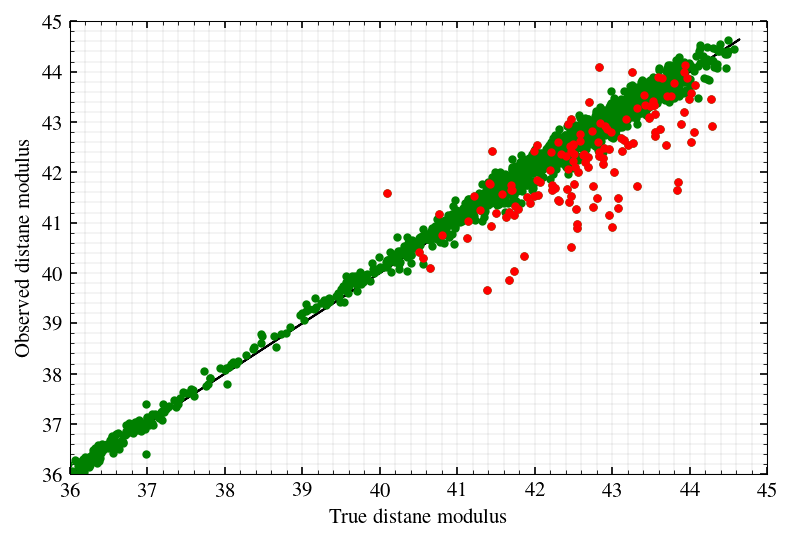

In [7]:
if (1): #check data

    fname = 'data/DES_SNIa/hubble_diagram.txt'
    sne_arr, z_arr, mu_arr, muerr_stat_arr, muerr_vpec_arr, muerr_sys_arr, prob_arr = np.loadtxt(fname, skiprows = 9, usecols = [1, 4, 5, 6, 7, 8, 9], unpack = True)
    print(prob_arr.shape)
    
    paramfile = 'data/params.ini'
    baselinecosmo = 'Flatw0waCDM'
    param_dict = misc.get_param_dict(paramfile)


    #DES-Y5
    desy5_sne_details_dic = sne_cmb_fisher_tools.get_sne_details('des', obtain_covs = False)
    desy5cobaya_sne_details_dic = sne_cmb_fisher_tools.get_sne_details('des_cobaya', obtain_covs = False)
    
    sne_dic = {'des': desy5_sne_details_dic}#, 'des_cobaya': desy5cobaya_sne_details_dic}
    pl_dic = {}
    for key in sne_dic:
        muarr = sne_dic[key]['sne_muarr']
        zarr = sne_dic[key]['sne_zarr']
        cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)
        muarr_ideal = np.asarray( [cosmo.distmod(z).value for z in zarr] )
        pl_dic[key] = [zarr, muarr, muarr_ideal]
        
    
    for key in pl_dic:
        clf()
        zarr, muarr, muarr_ideal = pl_dic[key]
        bad_inds = np.where(prob_arr<0.8)[0]
        plot(muarr_ideal, muarr_ideal, 'k-')
        plot(muarr, muarr_ideal, 'green', marker = '.', ls = 'None')
        plot(muarr[bad_inds], muarr_ideal[bad_inds], 'r.', ls = 'None')
        xlim(36., 45.); ylim(36., 45.)
        xlabel(r'True distane modulus')
        ylabel(r'Observed distane modulus')
        grid(True, which = 'both', axis = 'both', lw = 0.2, alpha = 0.2)
        show()
    

In [8]:
import getdist
from getdist import plots, MCSamples
param_limits_dic = {'omch2': [0.05, 0.2], 'ws': [-1.5, -0.5], 'wa': [-1., 1.]}

chains_dic = {
              'lsst_binned_lcdm_ideal': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_lcdm_ideal/', 'lsst_binned_lcdm_ideal', 'LSST-Y3 SNe-Ia (Ideal): $\Lambda$CDM'],
              ##'lsst_binned_lcdm': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_lcdm/', 'lsst_binned_lcdm', LSST-Y3 SNe-Ia: $\Lambda$CDM'],
              ##'lsst_binned_lcdm_snana_ideal': ['chains/sne_likelihoods/snana_cosmo/cobaya/lsst_binned/lsst_binned_lcdm_ideal/', 'lsst_binned_lcdm_ideal', 'LSST-Y3 SNe-Ia (SNANA Ideal): $\Lambda$CDM'],    
              'lsst_unbinned_lcdm_ideal': ['chains/sne_likelihoods/cobaya/lsst_unbinned/lsst_unbinned_lcdm_ideal/', 'lsst_unbinned_lcdm_ideal', 'LSST-Y3 SNe-Ia Unbinned (Ideal): $\Lambda$CDM'],
              'des_lcdm_ideal': ['chains/sne_likelihoods/cobaya/des/des_lcdm_ideal/', 'des_lcdm_ideal', 'DES-Y5 SNe-Ia (Ideal): $\Lambda$CDM'],

              'lsst_binned_w0lcdm_ideal': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_w0lcdm_ideal/', 'lsst_binned_w0lcdm_ideal', 'LSST-Y3 SNe-Ia (Ideal): $w_{0} \Lambda$CDM'],
              ##'lsst_binned_w0lcdm': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_w0lcdm/', 'lsst_binned_w0lcdm', 'LSST-Y3 SNe-Ia: $w_{0} \Lambda$CDM'],
              ##'lsst_binned_w0lcdm_snana_ideal': ['chains/sne_likelihoods/snana_cosmo/cobaya/lsst_binned/lsst_binned_w0lcdm_ideal/', 'lsst_binned_w0lcdm_ideal', 'LSST-Y3 SNe-Ia (SNANA Ideal): $w_{0} \Lambda$CDM'],
              'lsst_unbinned_w0lcdm_ideal': ['chains/sne_likelihoods/cobaya/lsst_unbinned/lsst_unbinned_w0lcdm_ideal/', 'lsst_unbinned_w0lcdm_ideal', 'LSST-Y3 SNe-Ia Unbinned (Ideal): $w_{0} \Lambda$CDM'],
              'des_w0lcdm_ideal': ['chains/sne_likelihoods/cobaya/des/des_w0lcdm_ideal/', 'des_w0lcdm_ideal', 'DES-Y5 SNe-Ia (Ideal): $w_{0} \Lambda$CDM'],

              'lsst_binned_w0walcdm_ideal': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_w0walcdm_ideal/', 'lsst_binned_w0walcdm_ideal', 'LSST-Y3 SNe-Ia (Ideal): $w_{0}w_{a} \Lambda$CDM'],
              ##'lsst_binned_w0walcdm_snana_ideal': ['chains/sne_likelihoods/snana_cosmo/cobaya/lsst_binned/lsst_binned_w0walcdm_ideal/', 'lsst_binned_w0walcdm_ideal', 'LSST-Y3 SNe-Ia (SNANA Ideal): $w_{0}w_{a} \Lambda$CDM'],
              ###'des_w0walcdm_ideal': ['chains/sne_likelihoods/cobaya/des/des_w0walcdm_ideal/', 'DES-Y5 SNe-Ia (Ideal): $w_{0}w_{a} \Lambda$CDM'],
              #'lsst_binned_w0walcdm': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_w0walcdm/', 'LSST-Y3 SNe-Ias: $w_{0}w_{a} \Lambda$CDM'],
              #'lsst_binned_hw0walcdm': ['chains/sne_likelihoods/cobaya/lsst_binned/lsst_binned_hw0walcdm/', 'LSST-Y3 SNe-Ias: $H_{0}$ + $w_{0}w_{a} \Lambda$CDM'],
              #'sne_dist_mod': ['chains/lssty3sne_checks/', 'Check LSST-Y3 SNe-Ia: $w_{0}w_{a} \Lambda$CDM'],
              ##'des_w0walcdm_ideal': ['chains/sne_likelihoods/des/des_w0walcdm_ideal/', 'DES-Y5 SNe-Ia (Ideal): $w_{0}w_{a} \Lambda$CDM'],
              #'sne_des_w0walcdm': ['chains/sne_likelihoods/ideal_data/des/sne_des_w0walcdm/', 'DES-Y5 SNe-Ia: $w_{0}w_{a} \Lambda$CDM'],
              #'sne_des_cobaya_w0walcdm': ['chains/sne_likelihoods/ideal_data/des_cobaya/sne_des_cobaya_w0walcdm/', 'DES-Y5 (Cobaya) SNe-Ia: $w_{0}w_{a} \Lambda$CDM'],
             }

if (0): #DES-cobaya results for different configs.
    pass
    '''
    chains_dic = {
                  'des_cobaya_w0walcdm': ['chains/sne_likelihoods/restricted_priors/cobaya/des_cobaya/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5: $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_weighted': ['chains/sne_likelihoods/restricted_priors/cobaya/des_cobaya/with_weights/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_marg': ['chains/sne_likelihoods/restricted_priors/cobaya/des_cobaya/marginalize_abs_mag/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 marg: $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_marg_weighted': ['chains/sne_likelihoods/restricted_priors/cobaya/des_cobaya/marginalize_abs_mag/with_weights/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                }
    '''
if (0): #DES-cobaya vs LSST
    pass
    '''
    chains_dic = {
                  'des_cobaya_w0lcdm_marg_weighted': ['chains/sne_likelihoods/cobaya/des_cobaya/marginalize_abs_mag/with_weights/des_cobaya_w0lcdm/', 'des_cobaya_w0lcdm', 'DES-Y5 marg+weighted: $w_{0} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_marg_weighted': ['chains/sne_likelihoods/cobaya/des_cobaya/marginalize_abs_mag/with_weights/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_withscriptM_weighted': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/fit_for_scriptM/with_weights/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 weighted+$\mathcal{M}$: $w_{0}w_{a} \Lambda$CDM'],
                  'des_w0lcdm_marg_weighted': ['chains/sne_likelihoods/cobaya/des/marginalize_abs_mag/with_weights/des_w0lcdm/', 'des_w0lcdm', 'DES-Y5-sim marg+weighted: $w_{0} \Lambda$CDM'],
                  'des_w0walcdm_marg_weighted': ['chains/sne_likelihoods/cobaya/des/marginalize_abs_mag/with_weights/des_w0walcdm/', 'des_w0walcdm', 'DES-Y5-sim marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0lcdm_marg_weighted_sim1': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim1/marginalize_abs_mag/with_weights/lsst_unbinned_w0lcdm/', 'lsst_unbinned_w0lcdm', 'LSST-Y3 marg+weighted: $w_{0} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim1': ['chains/sne_likelihoods/camb/cobaya/lsst_unbinned/sim1/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  #'lsst_unbinned_w0walcdm_weighted_sim1': ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim1/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1 weighted: $w_{0}w_{a} \Lambda$CDM'],
                  #'lsst_unbinned_w0walcdm_withscriptM_weighted_sim1': ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim1/fit_for_scriptM/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1 weighted + $\mathcal{M}$: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim1': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim1/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim2': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim1/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-2 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim3': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim2/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-3 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim4': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim3/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-4 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_marg_weighted_sim5': ['chains/sne_likelihoods/cobaya/lsst_unbinned/sim4/marginalize_abs_mag/with_weights/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-5 marg+weighted: $w_{0}w_{a} \Lambda$CDM'],
                }
    '''
    '''
    chains_dic = {
                  'des_cobaya_w0walcdm_astropy': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 (astropy): $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_w0walcdm_camb': ['chains/sne_likelihoods/camb/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 (CAMB): $w_{0}w_{a} \Lambda$CDM'],
                }
    '''
    '''
    which_sim = 3
    chains_dic = {
                  'des_cobaya_w0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5 (astropy): $w_{0}w_{a} \Lambda$CDM'],
                  'des_w0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des/with_weights/fit_for_scriptM/des_w0walcdm/', 'des_w0walcdm', 'DES-Y5 Sim: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_sim1': ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim1/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1: $w_{0}w_{a} \Lambda$CDM'],                  
                  'lsst_unbinned_w0walcdm_sim%s' %(which_sim): ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim%s/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/' %(which_sim), 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-%s: $w_{0}w_{a} \Lambda$CDM' %(which_sim)],
                  'lsst_unbinned_w0walcdm_sim%s_zmin0.2' %(which_sim): ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/zmin0.2/sim%s/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/' %(which_sim), 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-%s ($z \ge 0.2$): $w_{0}w_{a} \Lambda$CDM' %(which_sim)],
                  'lsst_unbinned_w0walcdm_sim%s_zmax1.0' %(which_sim): ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/zmax1.0/sim%s/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/' %(which_sim), 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-%s ($z \le 1$): $w_{0}w_{a} \Lambda$CDM' %(which_sim)],
                  ###'lsst_unbinned_w0walcdm_sim%s_zmax1.1' %(which_sim): ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/zmax1.1/sim%s/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/' %(which_sim), 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-%s ($z \le 1.1$): $w_{0}w_{a} \Lambda$CDM' %(which_sim)],
                  'lsst_unbinned_w0walcdm_sim%s_zmin0.2_zmax1.0' %(which_sim): ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/zmin0.2_zmax1.0/sim%s/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/' %(which_sim), 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-%s ($z \in [0.2, 1]$): $w_{0}w_{a} \Lambda$CDM' %(which_sim)],
                }
    '''
    chains_dic = {
                  'des_cobaya_w0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5: $w_{0}w_{a} \Lambda$CDM'],
                  'des_w0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des/with_weights/fit_for_scriptM/des_w0walcdm/', 'des_w0walcdm', 'DES-Y5 Sim: $w_{0}w_{a} \Lambda$CDM'],
                  'lsst_unbinned_w0walcdm_sim1': ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim1/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-1: $w_{0}w_{a} \Lambda$CDM'],                  
                  'lsst_unbinned_w0walcdm_sim3': ['chains/sne_likelihoods/astropy/cobaya/lsst_unbinned/sim3/with_weights/fit_for_scriptM/lsst_unbinned_w0walcdm/', 'lsst_unbinned_w0walcdm', 'LSST-Y3 Sim-3: $w_{0}w_{a} \Lambda$CDM'],                  
                }

    #fit for H
    chains_dic = {
                  'des_cobaya_w0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_w0walcdm/', 'des_cobaya_w0walcdm', 'DES-Y5: $w_{0}w_{a} \Lambda$CDM'],
                  'des_cobaya_hw0walcdm': ['chains/sne_likelihoods/astropy/cobaya/des_cobaya/with_weights/fit_for_scriptM/des_cobaya_hw0walcdm/', 'des_cobaya_hw0walcdm', 'DES-Y5: $h + w_{0}w_{a} \Lambda$CDM'],
                }
        
burn_in_percent = 0.3
samples_dic = {}
for chainkeyname in chains_dic:
    chain_loc, chainname, chain_lab = chains_dic[chainkeyname]
    curr_samples = getdist.mcsamples.loadMCSamples('%s/%s' %(chain_loc, chainname))
    p = curr_samples.getParams()
    curr_samples.addDerived(p.omch2 / 0.67**2, name='omegam', label=r'\Omega_\mathrm{m}')
    curr_samples.removeBurn(burn_in_percent)
    print( chainkeyname, len(curr_samples.samples), curr_samples.getParamNames().list() )
    samples_dic[chainkeyname] = curr_samples
    print( '\t', curr_samples.getLatex(['omch2', 'omegam', 'ws', 'wa', 'scriptM']), '\n' )
    
'''
#grid logL
print('\ngrid logL')
parent_logL_grid = sne_cmb_fisher_tools.get_and_process_logL_grid(chains_dic)
'''

param_limits_dic = {'omch2': [0., 0.5], 'ws': [-3., 3], 'wa': [-3, 3]}

des_cobaya_w0walcdm 3136 ['omch2', 'ws', 'wa', 'scriptM', 'chi2', 'chi2__sne_dist_mod', 'omegam']
	 (['\\Omega_\\mathrm{c} h^2', '\\Omega_\\mathrm{m}', 'w_0', 'w_a', '\\mathcal{M}'], ['0.234^{+0.018}_{-0.012}', '0.521^{+0.040}_{-0.028}', '0.04^{+0.33}_{-0.47}', '-12.6^{+5.6}_{-4.1}', '0.005^{+0.018}_{-0.020}']) 

des_cobaya_hw0walcdm 12600 ['omch2', 'h', 'ws', 'wa', 'scriptM', 'chi2', 'chi2__sne_dist_mod', 'omegam']
	 (['\\Omega_\\mathrm{c} h^2', '\\Omega_\\mathrm{m}', 'w_0', 'w_a', '\\mathcal{M}'], ['0.33^{+0.14}_{-0.11}', '0.74^{+0.31}_{-0.25}', '0.01^{+0.33}_{-0.45}', '-12.4^{+5.6}_{-4.1}', '0.31^{+0.54}_{-0.20}']) 



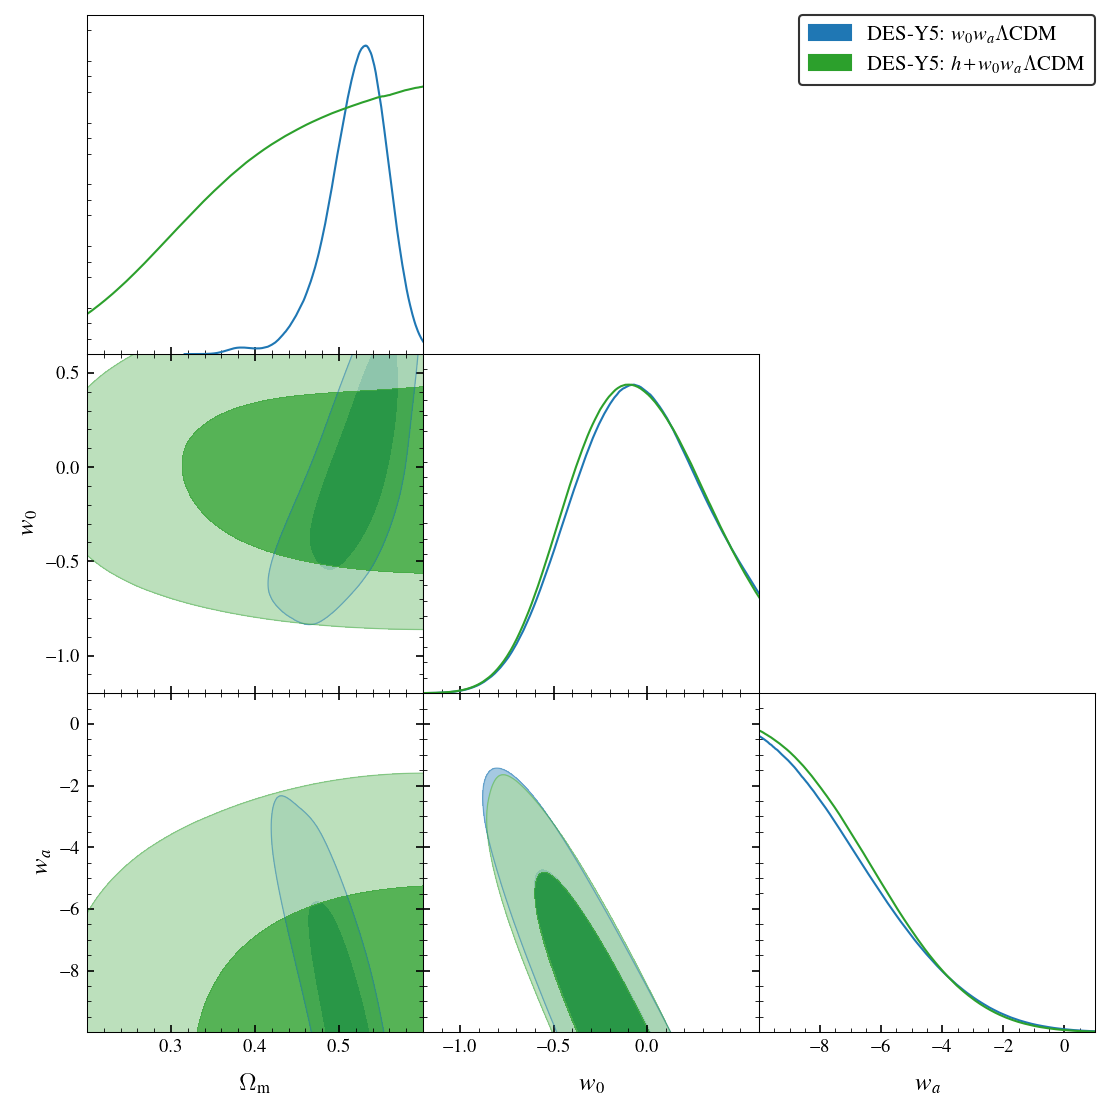

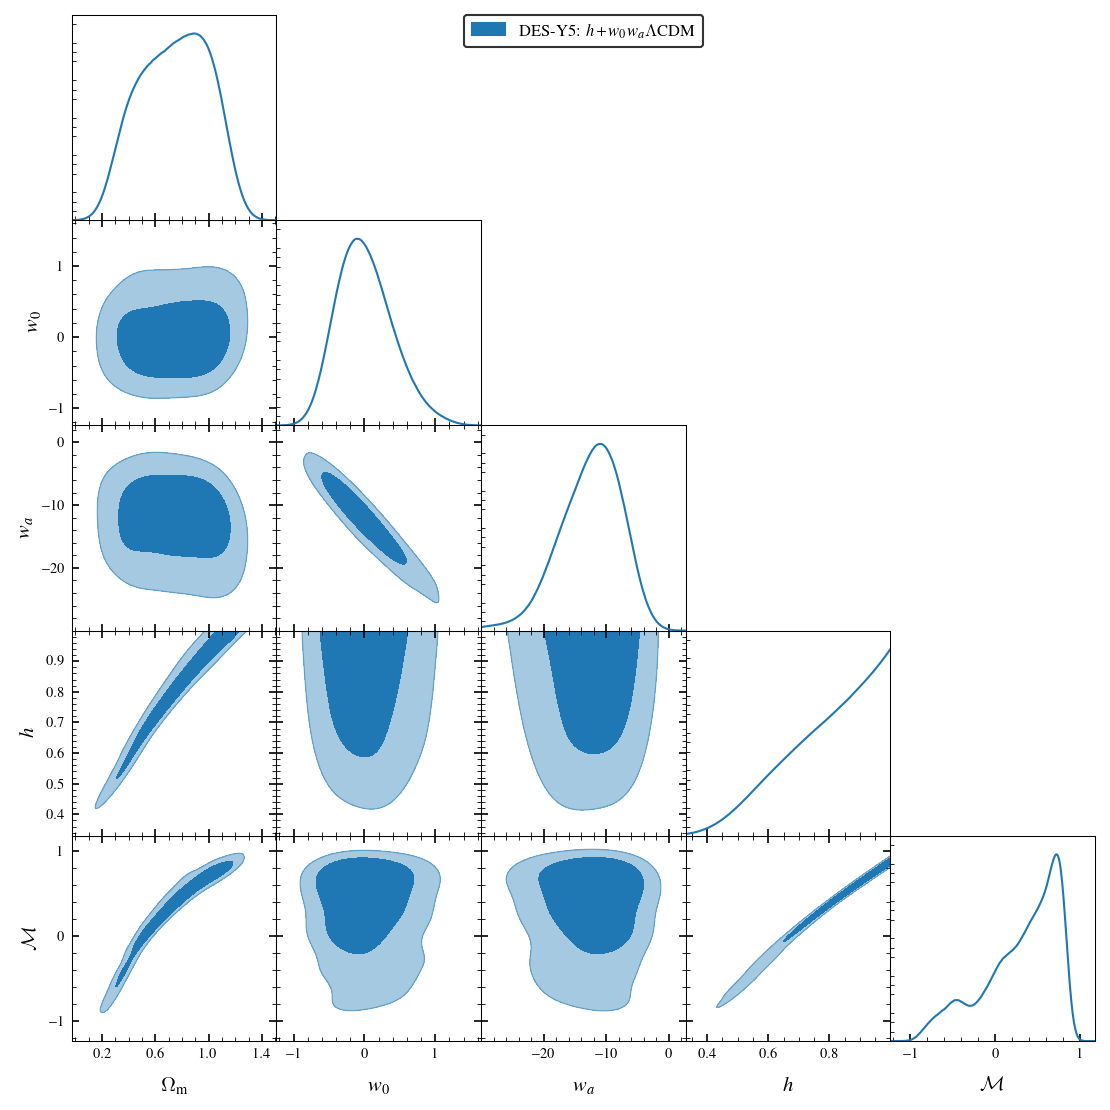

SystemExit: 

In [17]:
if (1): #
    
    
    param_limits_dic = {'omegam': [0.1, 0.6], 'ws': [-2, 0.], 'wa': [-3, 3.], 'h': [0., 1.2]}
    param_limits_dic = {'omegam': [0.2, 0.6], 'ws': [-1.2, 0.6], 'wa': [-10, 1.]}
    chains_to_plot = ['des_cobaya_w0walcdm', 'des_cobaya_hw0walcdm']#, 'des_w0walcdm', 'des_hw0walcdm']
    #chains_to_plot = ['des_cobaya_w0walcdm', 'des_w0walcdm', 'lsst_unbinned_w0walcdm_sim1']#, 'des_w0walcdm', 'des_hw0walcdm']
    
    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
        labels_arr.append( labval )    

    g = plots.get_subplot_plotter(width_inch=7.5)
    g.settings.scaling = True
    g.settings.alpha_filled_add=0.8
    #params_to_plot = ['omegam', 'ws', 'wa', 'scriptM']
    params_to_plot = ['omegam', 'ws', 'wa']
    g.triangle_plot(samples_to_plot, params=params_to_plot, filled=True, \
                    legend_labels = labels_arr, \
                    param_limits = param_limits_dic, \
                    contour_colors=['tab:blue', 'tab:green', 'tab:red', 'purple', 'black'], 
                    line_args=[{'lw':1, 'color':'tab:blue'},
                               {'lw':1, 'color':'tab:green'}, 
                               {'lw':1, 'color':'tab:red'}, 
                               {'lw':1, 'color':'purple'}, 
                               {'lw':1, 'color':'black'},], 
                   )#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)

    show(); #sys.exit()
    
    #traingle plot with Hubble constant.
    param_limits_dic = {'omegam': [0.1, 0.6], 'ws': [-2, 0.], 'wa': [-3, 3.], 'h': [0., 1.2]}
    chains_to_plot = ['des_cobaya_hw0walcdm']#, 'des_hw0walcdm']
    
    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
        labels_arr.append( labval )    
        
    g = plots.get_subplot_plotter(width_inch=7.5)
    g.settings.scaling = True
    g.settings.alpha_filled_add=0.8
    g.triangle_plot(samples_to_plot, params=['omegam', 'ws', 'wa', 'h', 'scriptM'], filled=True, \
                    legend_labels = labels_arr, 
                    #param_limits = param_limits_dic, \
                    contour_colors=['tab:blue', 'tab:green', 'tab:red', 'purple', 'black'], 
                    line_args=[{'lw':1, 'color':'tab:blue'},
                               {'lw':1, 'color':'tab:green'}, 
                               {'lw':1, 'color':'tab:red'}, 
                               {'lw':1, 'color':'purple'}, 
                               {'lw':1, 'color':'black'},], 
                   )#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)

    show(); sys.exit()    
    
    #traingle plot for different DES cases
    param_limits_dic = {'omegam': [0.26, 0.6], 'ws': [-1.1, 0.5], 'wa': [-13, 1.]}
    #param_limits_dic = {'omegam': [0.1, 0.6], 'ws': [-2, 0.], 'wa': [-3, 3.]}
    #chains_to_plot = ['des_cobaya_w0walcdm']#, 'des_cobaya_w0walcdm_weighted', 'des_cobaya_w0walcdm_marg', 'des_cobaya_w0walcdm_marg_weighted']
    chains_to_plot = [#'des_cobaya_w0walcdm_marg_weighted', 
                      #'des_cobaya_w0walcdm_withscriptM_weighted', 
                      #'des_w0walcdm_marg_weighted', 
                      #'lsst_unbinned_w0walcdm_marg_weighted_sim3', 
                      #'lsst_unbinned_w0walcdm_weighted_sim1',
                      #'des_cobaya_w0walcdm_astropy', 
                      #'des_cobaya_w0walcdm_camb', 
                      ###'des_cobaya_w0walcdm', 
                      'des_w0walcdm', 
                      ###'lsst_unbinned_w0walcdm_sim1_zmin0.2_zmax1.0',
                      ###'lsst_unbinned_w0walcdm_sim1_zmin0.2', 
                      ###'lsst_unbinned_w0walcdm_sim1_zmax1.0', 
                      ###'lsst_unbinned_w0walcdm_sim1_zmax1.1', 
                      ###'lsst_unbinned_w0walcdm_sim1', 
        
                      'lsst_unbinned_w0walcdm_sim3', 
                      'lsst_unbinned_w0walcdm_sim3_zmin0.2_zmax1.0', 
                      'lsst_unbinned_w0walcdm_sim3_zmin0.2', 
                      'lsst_unbinned_w0walcdm_sim3_zmax1.0', 
                      ]
    
    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
        labels_arr.append( labval )    
    g = plots.get_subplot_plotter(width_inch=7.5)
    g.settings.scaling = True
    g.settings.alpha_filled_add=0.8
    g.triangle_plot(samples_to_plot, params=['omegam', 'ws', 'wa'], filled=True, \
                    legend_labels = labels_arr, param_limits = param_limits_dic, \
                    contour_colors=['tab:blue', 'tab:green', 'tab:red', 'purple', 'black'], 
                    line_args=[{'lw':1, 'color':'tab:blue'},
                               {'lw':1, 'color':'tab:green'}, 
                               {'lw':1, 'color':'tab:red'}, 
                               {'lw':1, 'color':'purple'}, 
                               {'lw':1, 'color':'black'},], 
                   )#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)

    show(); sys.exit()
    
    chains_to_plot = ['des_cobaya_w0lcdm_marg_weighted', 'des_w0lcdm_marg_weighted', 'lsst_unbinned_w0lcdm_marg_weighted_sim1']
    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
        labels_arr.append( labval )    
    g = plots.get_subplot_plotter(width_inch=2.5)
    g.settings.scaling = True
    g.plots_2d(samples_to_plot, param_pairs=[['omegam', 'ws']], filled=True, \
               param_limits = param_limits_dic, legend_labels = labels_arr, \
               colors=['navy', 'goldenrod', 'orangered'], #, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names)
               lims = [0.18, 0.44, -1.5, -0.6],
              )

    show(); sys.exit()
    
    
    
    #traingle plot for different DES cases
    #chains_to_plot = ['des_cobaya_w0walcdm']#, 'des_cobaya_w0walcdm_weighted', 'des_cobaya_w0walcdm_marg', 'des_cobaya_w0walcdm_marg_weighted']
    chains_to_plot = [#'lsst_unbinned_w0walcdm_weighted_sim1', 
                      'lsst_unbinned_w0walcdm_marg_weighted_sim1', 
                      'lsst_unbinned_w0walcdm_marg_weighted_sim2',
                      'lsst_unbinned_w0walcdm_marg_weighted_sim3',
                      'lsst_unbinned_w0walcdm_marg_weighted_sim4',
                      'lsst_unbinned_w0walcdm_marg_weighted_sim5',
                     ]
    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '').replace('LSST-Y3', '')
        labels_arr.append( labval )    
    g = plots.get_subplot_plotter(width_inch=7.5)
    g.settings.scaling = True
    g.triangle_plot(samples_to_plot, params=['omegam', 'ws', 'wa'], filled=True, \
                    legend_labels = labels_arr, #param_limits = param_limits_dic, \
                    contour_colors=['steelblue', 'darkgreen', 'darkgreen', 'goldenrod', 'orangered', 'darkred'])#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)
    show();     

0.12080755399172846


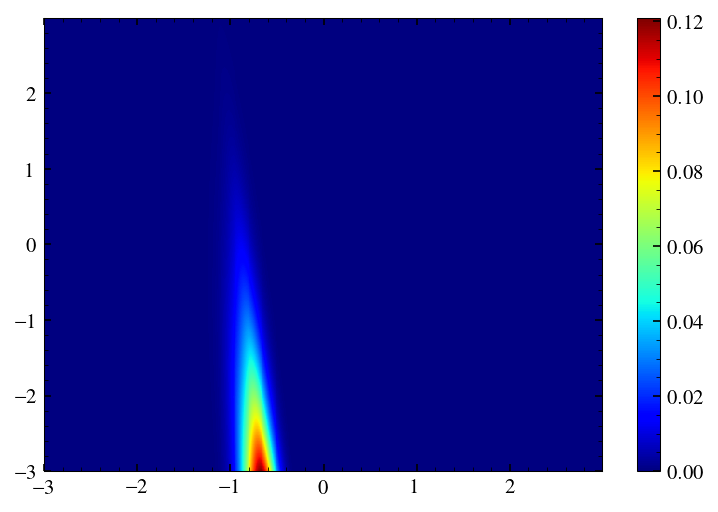

In [10]:
curr_samples_to_analyse = samples_dic[chainkeyname]
density =curr_samples_to_analyse.get2DDensity('wa','ws')
xarr = yarr = np.arange(-3, 3., 0.01)
xgrid, ygrid = np.meshgrid( xarr, yarr )
zgrid = density(xgrid[0,:], ygrid[:,0])
print(zgrid.max())
pcolormesh(xgrid, ygrid, zgrid); colorbar(); show()



In [209]:
curr_samples_to_analyse_1.getCombinedSamplesWithSamples??



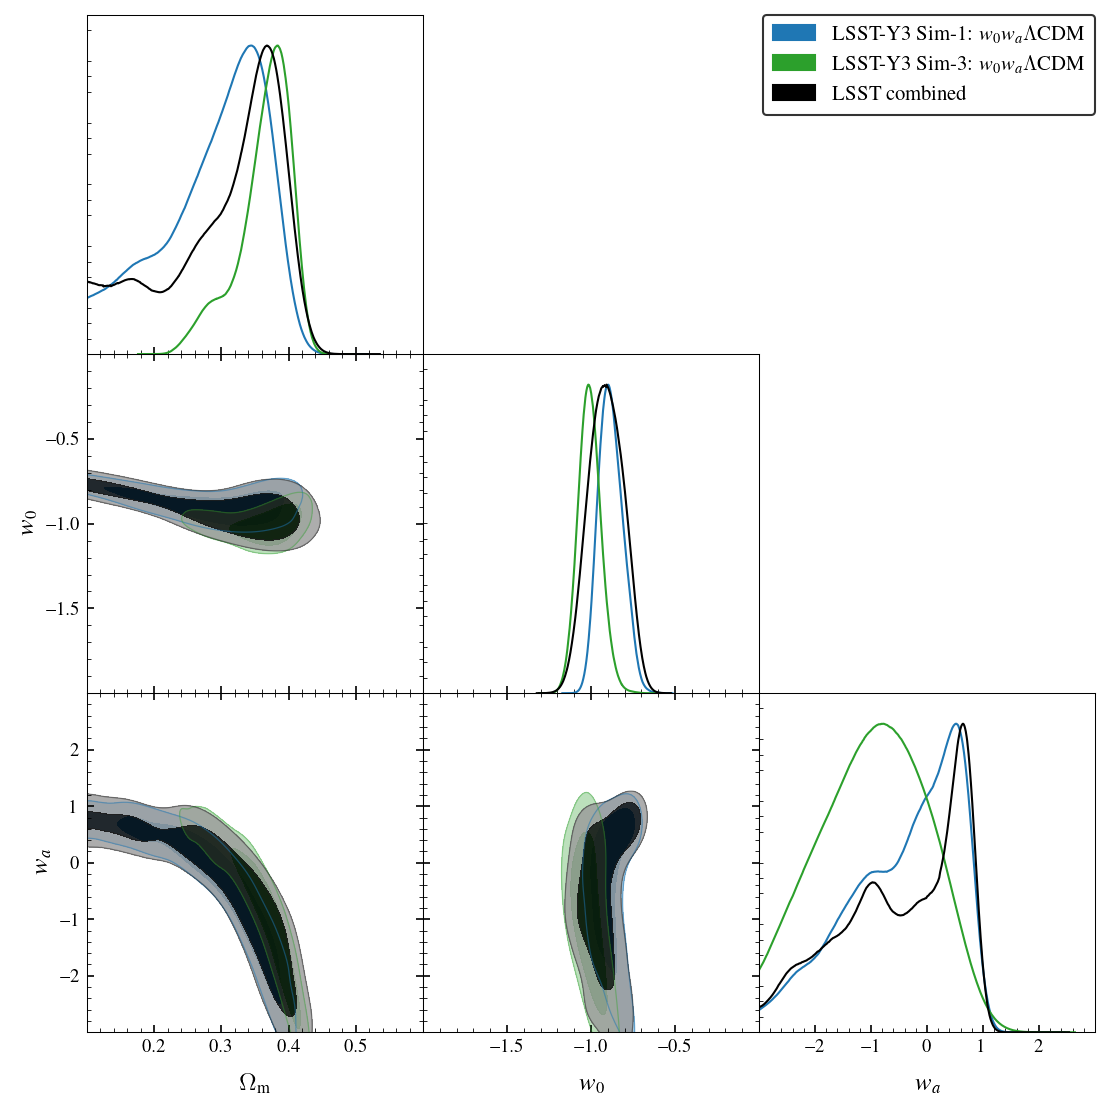

SystemExit: 

In [208]:
#combine chains
curr_samples_to_analyse_1 = samples_dic['lsst_unbinned_w0walcdm_sim1']
curr_samples_to_analyse_2 = samples_dic['lsst_unbinned_w0walcdm_sim3']
#samples_dic['lsst_unbinned_w0walcdm_combined'] = curr_samples_to_analyse_1.getCombinedSamplesWithSamples(curr_samples_to_analyse_2)
samples_dic['lsst_unbinned_w0walcdm_combined'] = curr_samples_to_analyse_1.getCombinedSamplesWithSamples(curr_samples_to_analyse_2, [curr_samples_to_analyse_1.weights, curr_samples_to_analyse_2.weights])

#single chain
param_limits_dic = {'omegam': [0.1, 0.6], 'ws': [-2, 0.], 'wa': [-3, 3.]}
chains_to_plot = ['lsst_unbinned_w0walcdm_sim1', 
                  'lsst_unbinned_w0walcdm_sim3', 
                  'lsst_unbinned_w0walcdm_combined', 
                  ]
samples_to_plot, labels_arr = [], []
for chainkeyname in chains_to_plot:
    samples_to_plot.append( samples_dic[chainkeyname] )
    if chainkeyname == 'lsst_unbinned_w0walcdm_combined':
        labval = r'LSST combined'
    else:
        labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
    labels_arr.append( labval )    
g = plots.get_subplot_plotter(width_inch=7.5)
g.settings.scaling = True
g.settings.alpha_filled_add=0.8
g.triangle_plot(samples_to_plot, params=['omegam', 'ws', 'wa'], filled=True, \
                legend_labels = labels_arr, param_limits = param_limits_dic, \
                contour_colors=['tab:blue', 'tab:green', 'black', 'purple', 'black'], 
                line_args=[{'lw':1, 'color':'tab:blue'},
                           {'lw':1, 'color':'tab:green'}, 
                           {'lw':1, 'color':'black'}, 
                           {'lw':1, 'color':'purple'}, 
                           {'lw':1, 'color':'black'},], 
               )

show(); sys.exit()


(['\\Omega_\\mathrm{c} h^2', 'w_0', 'w_a', '\\mathcal{M}', None, None, '\\Omega_\\mathrm{m}'], ['0.163^{+0.021}_{-0.0095}', '-1.009^{+0.063}_{-0.071}', '-1.02^{+1.2}_{-0.91}', '-0.0809\\pm 0.0080', None, None, '0.364^{+0.048}_{-0.021}'])
[[ 3.36806162e-04  2.19891402e-04 -1.72526692e-02  6.84189778e-05
  -3.89097252e-04 -3.89097252e-04  7.50292185e-04]
 [ 2.19891402e-04  4.65528132e-03 -3.83393456e-02  4.28902812e-04
   1.94381584e-02  1.94381584e-02  4.89844958e-04]
 [-1.72526692e-02 -3.83393456e-02  1.09383484e+00 -5.18691104e-03
  -2.54629110e-01 -2.54629110e-01 -3.84332128e-02]
 [ 6.84189778e-05  4.28902812e-04 -5.18691104e-03  6.40330590e-05
   3.73306826e-04  3.73306826e-04  1.52414742e-04]
 [-3.89097252e-04  1.94381584e-02 -2.54629110e-01  3.73306826e-04
   6.76933949e+00  6.76933949e+00 -8.66779354e-04]
 [-3.89097252e-04  1.94381584e-02 -2.54629110e-01  3.73306826e-04
   6.76933949e+00  6.76933949e+00 -8.66779354e-04]
 [ 7.50292185e-04  4.89844958e-04 -3.84332128e-02  1.5241474

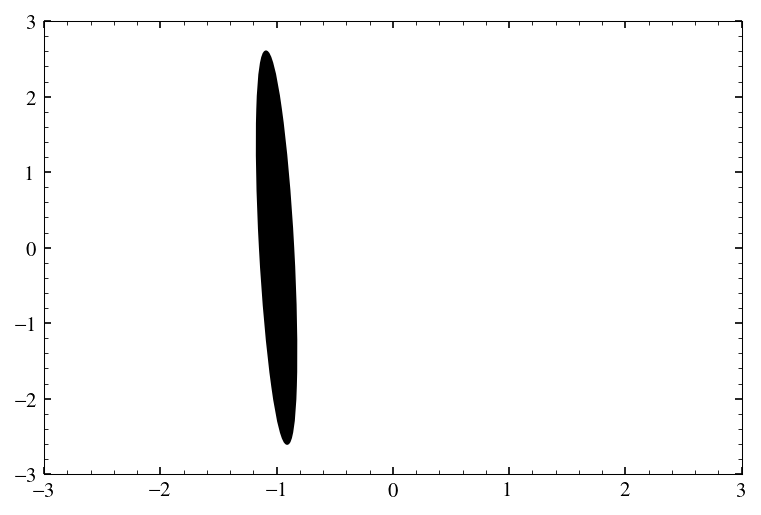

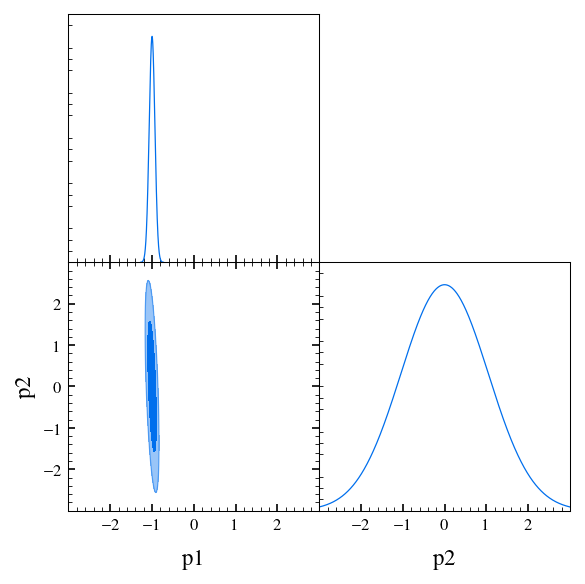

In [210]:
#get the covmat
curr_samples_to_analyse = samples_dic['lsst_unbinned_w0walcdm_sim3']
curr_params = curr_samples_to_analyse.getParamNames()
#print( curr_params )
errors = curr_samples_to_analyse.getLatex(['omch2', 'ws', 'wa', 'scriptM', 'chi2*', 'chi2__sne_dist_mod*', 'omegam'])
print( errors )
cov_mat = curr_samples_to_analyse.cov()
print(cov_mat)
print( np.diag(cov_mat)**0.5 )

pind1, pind2 = 1, 2
pcntr1, pcntr2 = pind1, pind2
cov_inds_to_extract = [(pcntr1, pcntr1), (pcntr1, pcntr2), (pcntr2, pcntr1), (pcntr2, pcntr2)]
cov_extract = np.asarray( [cov_mat[ii] for ii in cov_inds_to_extract] ).reshape((2,2))
print( cov_extract )

#imshow(cov_extract); colorbar(); show()
ax = subplot(111)
import matplotlib.patches as patches
x, y = -1., 0.
for iter in range(2):
    Ep = misc.get_ellipse_specs(cov_extract, howmanysigma = iter+1)
    widthval, heightval = Ep[0], Ep[1]
    print(widthval, heightval)

    ellipse = patches.Ellipse(xy=[x,y], width=2.*widthval, height=2.*heightval, angle=np.degrees(Ep[2]))

    colorval, lwval, lsval = 'black', 1., '-'
    ax.add_artist(ellipse)
    ellipse.set_clip_box(ax.bbox)
    ellipse.set_facecolor(colorval)
    ellipse.set_edgecolor(colorval)
    ellipse.set_linewidth(lwval)
    ellipse.set_linestyle(lsval)
    if iter == 0:
        ellipse.set_alpha(0.2)
    xlim(-3, 3.); ylim(-3, 3.)
show()


# The plotting scripts also let you plot Gaussian (or Gaussian mixture) contours 
# This is useful for plotting smooth theory results, e.g. Fisher forecasts.
param_limits_dic = {'p1': [-3, 3.], 'p2': [-3, 3.]}
from getdist.gaussian_mixtures import GaussianND
mean = [x, y] 
gauss=GaussianND(mean, cov_extract, names = ['p1', 'p2'])
g = plots.get_subplot_plotter()
g.triangle_plot(gauss,filled=True, param_limits = param_limits_dic)
show()


In [154]:
GaussianND??

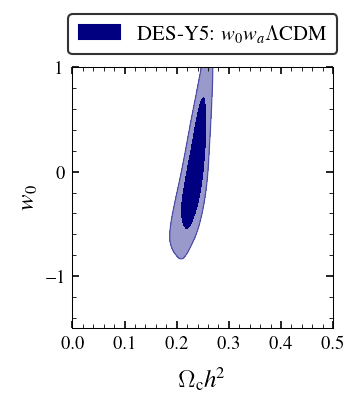




9.973125212949636 navy 0.3
16.72505770614535 navy 0.8


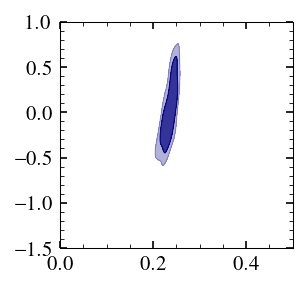

(200, 500) (200, 500) (500, 200)


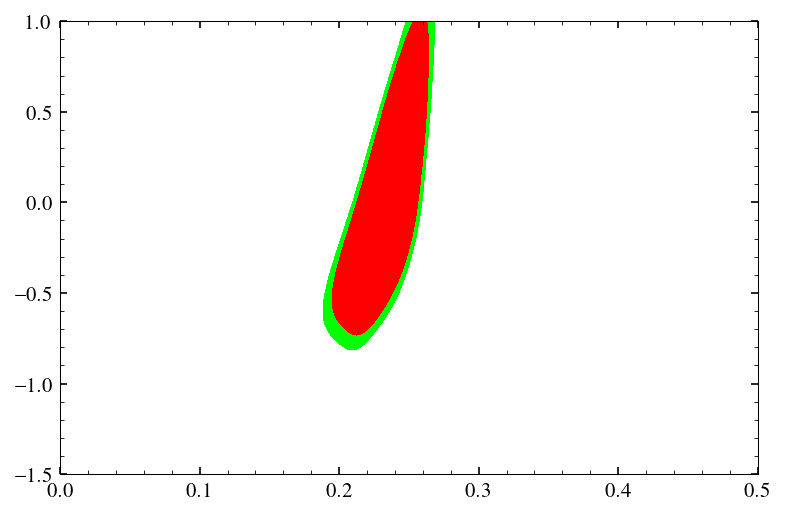

In [89]:
#chains_to_plot = ['des_cobaya_w0lcdm_marg_weighted', 'des_w0lcdm_marg_weighted', 'lsst_unbinned_w0lcdm_marg_weighted_sim1']
chains_to_plot = ['des_cobaya_w0walcdm']
samples_to_plot, labels_arr = [], []
for chainkeyname in chains_to_plot:
    samples_to_plot.append( samples_dic[chainkeyname] )
    labval = chains_dic[chainkeyname][2].replace('marg+weighted', '')
    labels_arr.append( labval )
g = plots.get_subplot_plotter(width_inch=2.5)
g.settings.scaling = True
g.plots_2d(samples_to_plot, param_pairs=[['omch2', 'ws']], filled=True, \
           param_limits = param_limits_dic, legend_labels = labels_arr, \
           colors=['navy', 'goldenrod', 'orangered'], #, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names)
           lims = [0., 0.5, -1.5, 1.],
          )

show(); ##sys.exit()

'''
print('\n\n')
close('all')
figure(figsize = (2, 2.))
ax = subplot(111)
color_arr=['navy', 'goldenrod', 'orangered']
for cntr, chainkeyname in enumerate( chains_to_plot ):
    curr_samples = samples_dic[chainkeyname]
    p = curr_samples.getParamNames()
    ###print(p); sys.exit()
    xgrid, ygrid, zgrid = misc.get_kde( curr_samples, 0, 1)
    misc.make_contour(ax, xgrid, ygrid, zgrid, color_arr = [color_arr[cntr], color_arr[cntr]])
xlim(0., 0.5); ylim(-1.5, 1.)
show()
'''

density=curr_samples.get2DDensity('omch2','ws')
print(density)
xarr = np.linspace(0, 1., 500)
yarr = np.linspace(-3, 3., 200)
xgrid, ygrid = np.meshgrid( xarr, yarr )
zgrid = density(xarr, yarr)
print(xgrid.shape, ygrid.shape, zgrid.shape)
#pcolormesh(xgrid, ygrid, zgrid); colorbar(); show()
#imshow(zgrid.T, extent = [np.min(xarr), np.max(xarr), np.min(yarr), np.max(yarr)], aspect='auto', origin = 'lower')

curr_level_1 = np.mean(zgrid) + np.std(zgrid)
curr_level_2 = np.mean(zgrid) + 2*np.std(zgrid)
curr_level_3 = np.mean(zgrid) + 3*np.std(zgrid)
curr_level_n = np.mean(zgrid) + 1e4*np.std(zgrid)
#contour(xgrid, ygrid, zgrid.T, levels = [curr_level_1, curr_level_n], colors =['w'])
contourf(xgrid, ygrid, zgrid.T, levels = [curr_level_1, curr_level_n], colors =['lime'])
contourf(xgrid, ygrid, zgrid.T, levels = [curr_level_2, curr_level_n], colors =['red'])
#contour(xgrid, ygrid, zgrid.T, levels = [curr_level_3], colors =['orangered'])
xlim(0., 0.5); ylim(-1.5, 1.)

show()


a omch2


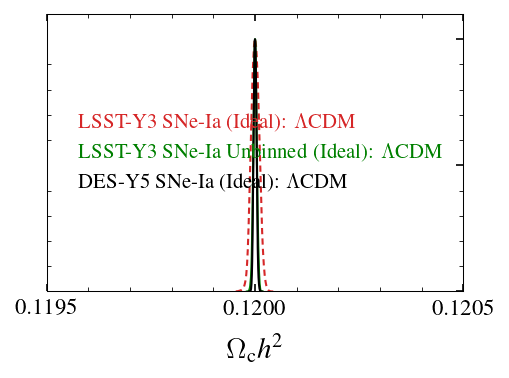

a omch2


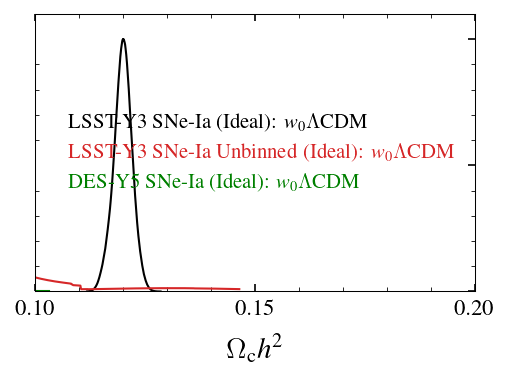

a ws


<Figure size 900x600 with 0 Axes>

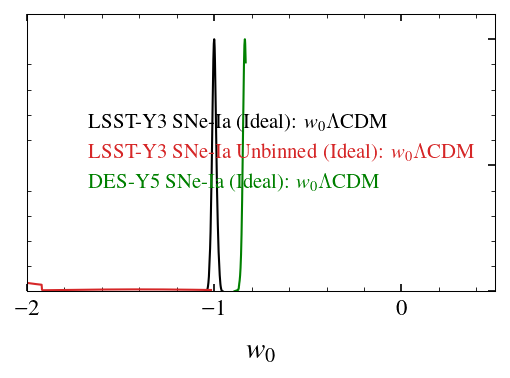

LinAlgError: Singular matrix

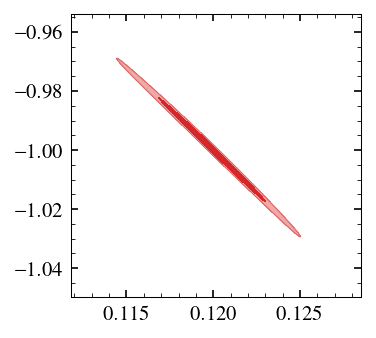

In [27]:
#1d and 2D plots for omch2 and w0
for iter in range(3):
    if iter == 0:        
        chains_to_plot = ['lsst_binned_lcdm_ideal', 'lsst_unbinned_lcdm_ideal', 'des_lcdm_ideal']#, 'lsst_binned_lcdm_snana_ideal'] #'lsst_binned_lcdm']#, 'lsst_binned_w0walcdm_ideal']#, 'sne_dist_mod']
    if iter == 1:        
        chains_to_plot = ['lsst_binned_w0lcdm_ideal', 'lsst_unbinned_w0lcdm_ideal', 'des_w0lcdm_ideal']#, 'lsst_binned_w0lcdm_snana_ideal']#, 'lsst_binned_w0lcdm']#, 'lsst_binned_w0walcdm_ideal']#, 'sne_dist_mod']
    elif iter == 2:
        chains_to_plot = ['lsst_binned_w0lcdm_ideal', 'lsst_unbinned_w0lcdm_ideal', 'des_w0lcdm_ideal']#, 'lsst_binned_w0lcdm_snana_ideal']#, 'lsst_binned_w0lcdm']#, 'lsst_binned_w0walcdm_ideal']#, 'sne_dist_mod']

    samples_to_plot, labels_arr = [], []
    for chainkeyname in chains_to_plot:
        samples_to_plot.append( samples_dic[chainkeyname] )
        labels_arr.append( chains_dic[chainkeyname][2] )    

    if iter == 0: #1d
        param_limits_dic = {'omch2': [0.1195, 0.1205]}
        #param_limits_dic = {'omch2': [0.15, 0.155]}
        #param_limits_dic = {'omch2': [0.1, 0.2]}
        g = plots.get_single_plotter(width_inch=3.5)
        g.settings.linewidth=1.
        g.plot_1d(samples_to_plot, 'omch2', param_limits = param_limits_dic, \
                  legend_labels = labels_arr, normalized = False, \
                  lims = [param_limits_dic['omch2'][0], param_limits_dic['omch2'][1]], \
                  colors=['tab:red', 'green', 'black', 'goldenrod'],
                  ls = ['--', '-'],
                 )
        g.add_legend(labels_arr, colored_text=True, fontsize = 10);
        
        '''
        #now show grid_log here
        clf()
        for chainkeyname in chains_to_plot:
            if chainkeyname not in parent_logL_grid: continue
            ret_arr = parent_logL_grid[chainkeyname]
            if len(ret_arr) == 2:
                xarr, Larr = ret_arr
                plot(xarr, Larr, ls = '-.', label = r'MLE on a grid')
            elif len(ret_arr) == 5:
                xarr, yarr, L_grid, L_arr_for_x, L_arr_for_y = ret_arr
                ##print(xarr, L_arr_for_x)
                plot(xarr, L_arr_for_x, ls = '-.')
        xlim(param_limits_dic['omch2'][0], param_limits_dic['omch2'][1])
        legend(loc = 2)
        '''
        show(); ##sys.exit()
    if iter == 1: #1d
        param_limits_dic = {'omch2': [0.1, 0.2]}
        g = plots.get_single_plotter(width_inch=3.5)
        g.plot_1d(samples_to_plot, 'omch2', param_limits = param_limits_dic, \
                  legend_labels = labels_arr, normalized = False, \
                  lims = [param_limits_dic['omch2'][0], param_limits_dic['omch2'][1]], \
                  colors=['black', 'tab:red', 'green', 'goldenrod'])
        g.add_legend(labels_arr, colored_text=True, fontsize = 10);
        
        '''
        for chainkeyname in chains_to_plot:
            if chainkeyname not in parent_logL_grid: continue
            ret_arr = parent_logL_grid[chainkeyname]
            if len(ret_arr) == 2:
                xarr, Larr = ret_arr
                plot(xarr, Larr, ls = '-.')
            elif len(ret_arr) == 5:
                xarr, yarr, L_grid, L_arr_for_x, L_arr_for_y = ret_arr
                ##print(xarr, L_arr_for_x)
                plot(xarr, L_arr_for_x, ls = '-.')
        '''
        show();
        
        clf()
        param_limits_dic = {'ws': [-2, 0.5]}
        g = plots.get_single_plotter(width_inch=3.5)
        g.plot_1d(samples_to_plot, 'ws', param_limits = param_limits_dic, \
                  legend_labels = labels_arr, normalized = False, \
                  lims = [param_limits_dic['ws'][0], param_limits_dic['ws'][1]], \
                  colors=['black', 'tab:red', 'green', 'goldenrod'])
        g.add_legend(labels_arr, colored_text=True, fontsize = 10);
        
        '''
        for chainkeyname in chains_to_plot:
            if chainkeyname not in parent_logL_grid: continue
            ret_arr = parent_logL_grid[chainkeyname]
            if len(ret_arr) == 2:
                xarr, Larr = ret_arr
                plot(xarr, Larr, ls = '-.')
            elif len(ret_arr) == 5:
                xarr, yarr, L_grid, L_arr_for_x, L_arr_for_y = ret_arr
                ##print(xarr, L_arr_for_x)
                plot(yarr, L_arr_for_y, ls = '-.')
        '''
        show(); ##sys.exit()            

    elif iter == 2: #2D
        param_limits_dic = {'omch2': [0.1, 0.2], 'ws': [-1.1, -0.9]}
        #param_limits_dic = {'omch2': [0., 1.], 'ws': [-3, 3]}
        g = plots.get_subplot_plotter(width_inch=2.5)
        g.settings.scaling = True
        g.plots_2d(samples_to_plot, param_pairs=[['omch2', 'ws']], filled=True, \
                   param_limits = param_limits_dic, legend_labels = labels_arr, \
                   colors=['tab:red', 'green'], #, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names)
                   #lims = [param_limits_dic['omch2'][0], param_limits_dic['omch2'][1], param_limits_dic['ws'][0], param_limits_dic['ws'][1]],
                  )

        show(); ##sys.exit() 
        '''
        for chainkeyname in chains_to_plot:
            if chainkeyname not in parent_logL_grid: continue
            ret_arr = parent_logL_grid[chainkeyname]
            if len(ret_arr) == 2: continue
            elif len(ret_arr) == 5:
                xarr, yarr, L_grid, L_arr_for_x, L_arr_for_y = ret_arr
            imshow( np.log(L_grid), aspect = 'auto' ); colorbar()
        '''
        show()
        

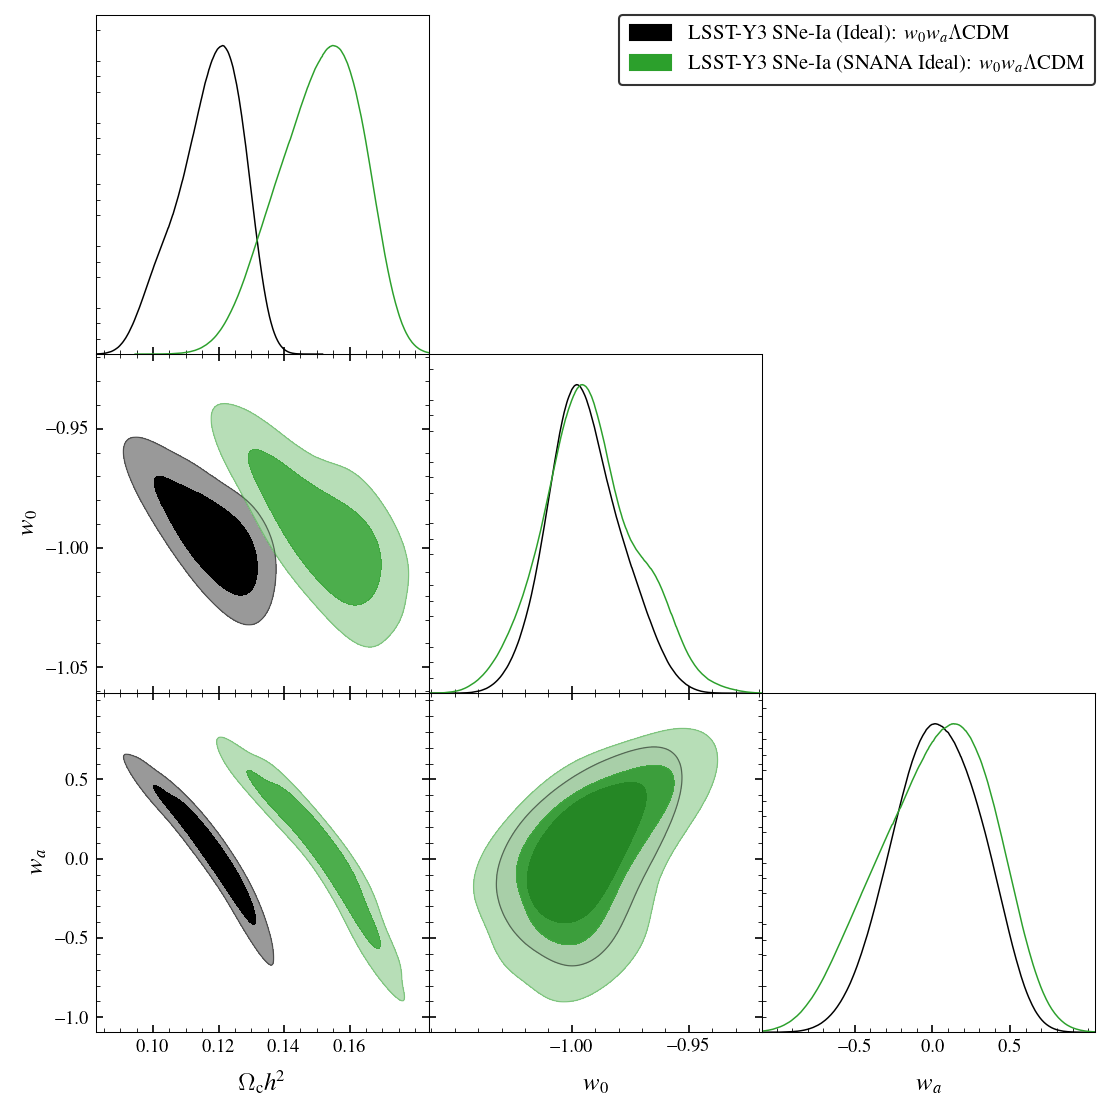

In [21]:
#traingle plot
#---- 
#https://arxiv.org/pdf/2401.02929
#Fig. 6.
chains_to_plot = ['lsst_binned_w0walcdm_ideal', 'lsst_binned_w0walcdm_snana_ideal']#, 'sne_dist_mod']#, 'des_w0walcdm_ideal']###'lsst_binned_w0walcdm', 'lsst_binned_hw0walcdm']#, 'sne_dist_mod', 'lsst_binned_w0walcdm_ideal']#, 'des_w0walcdm_ideal']#, 'lsst_binned_w0walcdm']
samples_to_plot, labels_arr = [], []
for chainkeyname in chains_to_plot:
    samples_to_plot.append( samples_dic[chainkeyname] )
    labels_arr.append( chains_dic[chainkeyname][2] )    
g = plots.get_subplot_plotter(width_inch=7.5)
g.settings.scaling = True # prevent scaling down font sizes even though small subplots
g.triangle_plot(samples_to_plot, params=['omch2', 'ws', 'wa'], filled=True, \
                legend_labels = labels_arr, #param_limits = param_limits_dic, \
                contour_colors=['black', 'tab:green', 'orangered'])#, contour_ls = ls_arr, contour_lw = lw_arr, legend_ncol = len(param_names), param_limits = param_limits_dic)
show(); 

In [14]:
if (1):
    cosmo = sne_cmb_fisher_tools.set_cosmo(param_dict, baselinecosmo = baselinecosmo)
    print( cosmo.distmod(1.) )
    
    print( )

44.22881833789404 mag



In [15]:
print('\n\nFisher matrix calculation starts\n\n')
if (0):##os.path.exists( master_fisher_dic_fname ):
    print('\tFisher matrices already obtained. Reading %s' %(master_fisher_dic_fname))
    master_fisher_dic = np.load(master_fisher_dic_fname, allow_pickle = True).item()
else:
    sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = True)
    sne_zarr = sne_details_dic['sne_zarr']
    sne_muarr = sne_details_dic['sne_muarr']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_muerr_sys = sne_details_dic['sne_muerr_sys']
    sne_muerr_stat = sne_details_dic['sne_muerr_stat']
    sne_stretch_x1_arr = sne_details_dic['sne_stretch_x1']
    sne_color_c_arr = sne_details_dic['sne_color_c']
    sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
    sne_params = sne_details_dic['sne_params']
    sne_sys_cov_dic = sne_details_dic['sne_sys_cov_dic']
    sne_stat_cov = sne_details_dic['sne_stat_cov']
    sne_tot_cov_dic = sne_details_dic['sne_tot_cov_dic']
    sne_tot_cov_inv_dic = sne_details_dic['sne_tot_cov_inv_dic']
    sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']
    
    master_fisher_dic = {}
    for curr_cov_tag in sne_cov_tag_dic:        
        print('SNe cov tag = %s' %(curr_cov_tag))

        parent_fisher_dic = {}
        for ziter in sne_z_bin_dic:

            #perform selection for the current z-bin
            zinds = np.where( (sne_zarr>sne_z_bin_dic[ziter][0]) & (sne_zarr<=sne_z_bin_dic[ziter][1]) )[0]
            curr_sne_zarr = sne_zarr[zinds]
            if sne_stretch_x1_arr is not None:
                curr_sne_stretch_x1_arr = sne_stretch_x1_arr[zinds]
            else:
                curr_sne_stretch_x1_arr = None
            if sne_color_c_arr is not None:
                curr_sne_color_c_arr = sne_color_c_arr[zinds]
            else:
                curr_sne_color_c_arr = None
            '''
            curr_sne_stat_cov = np.copy( sne_stat_cov )
            curr_sne_sys_cov = np.copy(sne_sys_cov_dic[curr_cov_tag])
            curr_sne_cov = curr_sne_stat_cov + curr_sne_sys_cov
            '''
            curr_sne_cov, curr_sne_cov_inv = None, None
            if sne_tot_cov_dic is not None:
                curr_sne_cov = np.copy(sne_tot_cov_dic[curr_cov_tag])
                curr_sne_cov = curr_sne_cov[zinds[:, None], zinds[None, :]]
            if sne_tot_cov_inv_dic is not None:
                curr_sne_cov_inv = np.copy(sne_tot_cov_inv_dic[curr_cov_tag])
                curr_sne_cov_inv = curr_sne_cov_inv[zinds[:, None], zinds[None, :]]


            '''
            if perform_random_z_selection:
                np.random.seed(111)
                howmany = 350
                zinds = np.random.choice( zinds, howmany, replace = False)
                zarr = zarr[zinds]
                ###print( zinds ); sys.exit()
            '''

            #get distance modules derivatives w.r.t cosmo params
            if 'omch2' in sne_params:
                use_hsq_units = True
            elif 'omega_m' in sne_params:
                use_hsq_units = False
            distance_modulus_deriv_dict = sne_cmb_fisher_tools.get_distance_modulus_derivatives(curr_sne_zarr, param_dict, sne_params, stretch_x1arr = curr_sne_stretch_x1_arr, color_carr = curr_sne_color_c_arr, baselinecosmo = baselinecosmo, use_hsq_units = use_hsq_units)

            '''
            if (0): #plot derivative
                color_dic = {'h': 'navy', 'omch2': 'darkgreen', 'w0': 'goldenrod', 'wa': 'orangered'}
                for ppp in params:    
                    ax = subplot(111)
                    der_arr = []
                    for z in zarr:
                        der_arr.append( distance_modulus_deriv_dict[z][ppp] )
                    plot(zarr, der_arr, color = color_dic[ppp], label = r'%s' %(misc.get_latex_param_str(ppp)))

                xlabel(r'Redshift $z$'); ylabel(r'$dDM/d\theta$')
                legend(loc = 2)
                show(); 
            '''

            #get Fisher
            lsst_dm_sne_fisher_mat = sne_cmb_fisher_tools.get_sne_distance_modulus_fisher(sne_params, curr_sne_cov, curr_sne_zarr, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
            ##print(lsst_dm_sne_fisher_mat); ##sys.exit()
            parent_fisher_dic[ziter] = lsst_dm_sne_fisher_mat

        master_fisher_dic[curr_cov_tag] = parent_fisher_dic
    print('\n\tDumping Fisher matrices into %s' %(master_fisher_dic_fname))
    ##np.save(master_fisher_dic_fname, master_fisher_dic)

print( '\n\n', master_fisher_dic.keys(), master_fisher_dic[0].keys() )




Fisher matrix calculation starts


Reading and process details for which_sne_data = lsst_binned
	Cov inv file = data/lsst_SNe//sne_lsst_binned_cov_inv.npy. Exists = True
		getting the covariance and cov inv for tag = 0 (Stat + sys-All)
		getting the covariance and cov inv for tag = 1 (Stat-only)
		getting the covariance and cov inv for tag = 2 (Stat + sys-ZSHIFT)
		getting the covariance and cov inv for tag = 3 (Stat + sys-ZERRSCALE)
		getting the covariance and cov inv for tag = 4 (Stat + sys-Photo_shift)
		getting the covariance and cov inv for tag = 5 (Stat + sys-MWEBV)
		getting the covariance and cov inv for tag = 6 (Stat + sys-Cal_ZP)
		getting the covariance and cov inv for tag = 7 (Stat + sys-Cal_wave)
		getting the covariance and cov inv for tag = 8 (Stat + sys-Cal)
SNe cov tag = 0
SNe cov tag = 1
SNe cov tag = 2
SNe cov tag = 3
SNe cov tag = 4
SNe cov tag = 5
SNe cov tag = 6
SNe cov tag = 7
SNe cov tag = 8

	Dumping Fisher matrices into results/lsst_binned//lsst_binned_sne_

In [16]:
if (0): # Plot derivatives

    if (0): #store the results for Clea
        tmpfname = 'results/lsst_binned/lsst_binned_sne_fisher_params--omega_m--ws--wa_zbins--z0.0-z3.0_forcomparison.npy'
        res_dic = {}
        res_dic['sne_zarr'] = sne_zarr
        res_dic['sne_muerr_stat'] = sne_muerr_stat
        res_dic['sne_muerr_sys'] = sne_muerr_sys
        res_dic['sne_params'] = sne_params
        res_dic['sne_sys_cov_dic'] = sne_sys_cov_dic
        res_dic['sne_stat_cov'] = sne_stat_cov
        res_dic['sne_tot_cov_dic'] = sne_tot_cov_dic
        res_dic['sne_tot_cov_inv_dic'] = sne_tot_cov_inv_dic
        res_dic['master_fisher_dic'] = master_fisher_dic
        res_dic['distance_modulus_deriv_dict'] = distance_modulus_deriv_dict
        np.save( tmpfname, res_dic )


    if (0):
        tmpfname = 'results/lsst_binned/lsst_binned_sne_fisher_params--omega_m--ws--wa_zbins--z0.0-z3.0_forcomparison.npy'
        res_dic = np.load(tmpfname, allow_pickle = True).item()
        print( res_dic.keys() )

        sne_params = res_dic['sne_params'] #Fisher matrix parameters
        sne_zarr = res_dic['sne_zarr'] #redshift of SNe
        print( sne_zarr.shape, sne_zarr )
        sne_muerr_stat = res_dic['sne_muerr_stat'] #statistical error only
        sne_stat_cov = res_dic['sne_stat_cov'] #statistical cov. Simply np.diag( sne_muerr_stat**2. )
        print( sne_stat_cov.shape )

        '''#not used here. Only used Fisher matrix bias calculations
        sne_muerr_sys = res_dic['sne_muerr_sys'] #systematic errors for each SNe.
        sne_sys_cov_dic = res_dic['sne_sys_cov_dic']
        sne_sys_cov_mat = sne_sys_cov_dic[0] #sys cov matrix.
        '''

        #total cov and inverse cov matrix of the SNe measurements. 
        sne_tot_cov_dic = res_dic['sne_tot_cov_dic'] #
        sne_tot_cov_inv_dic = res_dic['sne_tot_cov_inv_dic']
        sne_tot_cov_mat = sne_tot_cov_dic[0] #stat+sys cov matrix.
        sne_tot_cov_inv_mat = sne_tot_cov_inv_dic[0] #stat+sys inverse cov matrix.
        print( sne_tot_cov_mat.shape, sne_tot_cov_inv_mat.shape )

        #derivatives
        distance_modulus_deriv_dict = res_dic['distance_modulus_deriv_dict']
        print( distance_modulus_deriv_dict.keys(), distance_modulus_deriv_dict[sne_zarr[0]].keys() )

        master_fisher_dic = res_dic['master_fisher_dic']
        lsst_fisher_mat = master_fisher_dic[0][0] #Fisher matrix for the parameters
        print( lsst_fisher_mat.shape )
    
    #plot derivatives
    clf()
    fsval = 12
    figure(figsize = (8., 8.))
    subplots_adjust(wspace = 0.05, hspace = 0.05)
    color_arr = [cm.jet(int(d)) for d in np.linspace(0, 255, len(distance_modulus_deriv_dict))]
    #param_combs_dict = {('omch2', 'ws'): 1, ('omch2', 'wa'): 3, ('ws', 'wa'): 4}
    param_combs_dict = {('omega_m', 'ws'): 1, ('omega_m', 'wa'): 3, ('ws', 'wa'): 4}
    ax_lims_dict = {'ws': (-0.51, 0.01), 'wa': (-0.12, 0.01), 'omch2': (-4., 0.1), 'omega_m': (-1.8, 0.05)}
    for p1p2 in param_combs_dict:
        p1, p2 = p1p2
        sbpl = param_combs_dict[p1p2]
        ax = subplot(2, 2, sbpl)
        for cntr, curr_z in enumerate( sorted( distance_modulus_deriv_dict ) ):

            curr_deriv_ws = distance_modulus_deriv_dict[curr_z][p1]
            curr_deriv_wa = distance_modulus_deriv_dict[curr_z][p2]

            ##print( curr_z, curr_deriv_ws, curr_deriv_wa ); sys.exit()

            plot( curr_deriv_ws, curr_deriv_wa, 'o', color = color_arr[cntr])
            if sbpl == 1:
                textval = r'$z = %.2f$' %(curr_z)
                if cntr > 1:
                    textval = r'%.2f' %(curr_z)
                text( curr_deriv_ws-0.2, curr_deriv_wa+0.01, textval, color = color_arr[cntr], fontsize = fsval - 5, rotation = 0)
              
            xmin, xmax = ax_lims_dict[p1]
            ymin, ymax = ax_lims_dict[p2]
        
        xlim(xmin, xmax); ylim(ymin, ymax)
                        
        if sbpl >= 3:
            xlabel(r'$\partial{\mu}/\partial$%s' %(misc.get_latex_param_str(p1)), fontsize = fsval)
        else:
            setp(ax.get_xticklabels(), visible=False)

        if sbpl in [1, 3]:
            ylabel(r'$\partial{\mu}/\partial$%s' %(misc.get_latex_param_str(p2)), fontsize = fsval)
        else:
            setp(ax.get_yticklabels(), visible=False)

    ###savefig('plots/lsst_binned_sne_DM_derivatives_omegam_w0_wa.png', dpi = 200.)
    show()

In [17]:
sne_params

array(['omch2', 'ws', 'wa', 'M'], dtype='<U5')

{0: 'LSST SNe: $0 \\le z < 0.4$', 1: 'LSST SNe: $0 \\le z < 0.6$', 2: 'LSST SNe: $0 \\le z < 1$', 3: 'LSST SNe: $0 \\le z < 3$'}


"\n#save thr Fisher matrix\nopfname = 'data/lsst_SNe/fisher_sne_tmp.npy'\nop_dic = {}\nop_dic['fisher'] = master_fisher_dic\nop_dic['param_dict'] = param_dict\nop_dic['params'] = params\nprint(params)\nnp.save( opfname, op_dic )\n"

<Figure size 900x600 with 0 Axes>

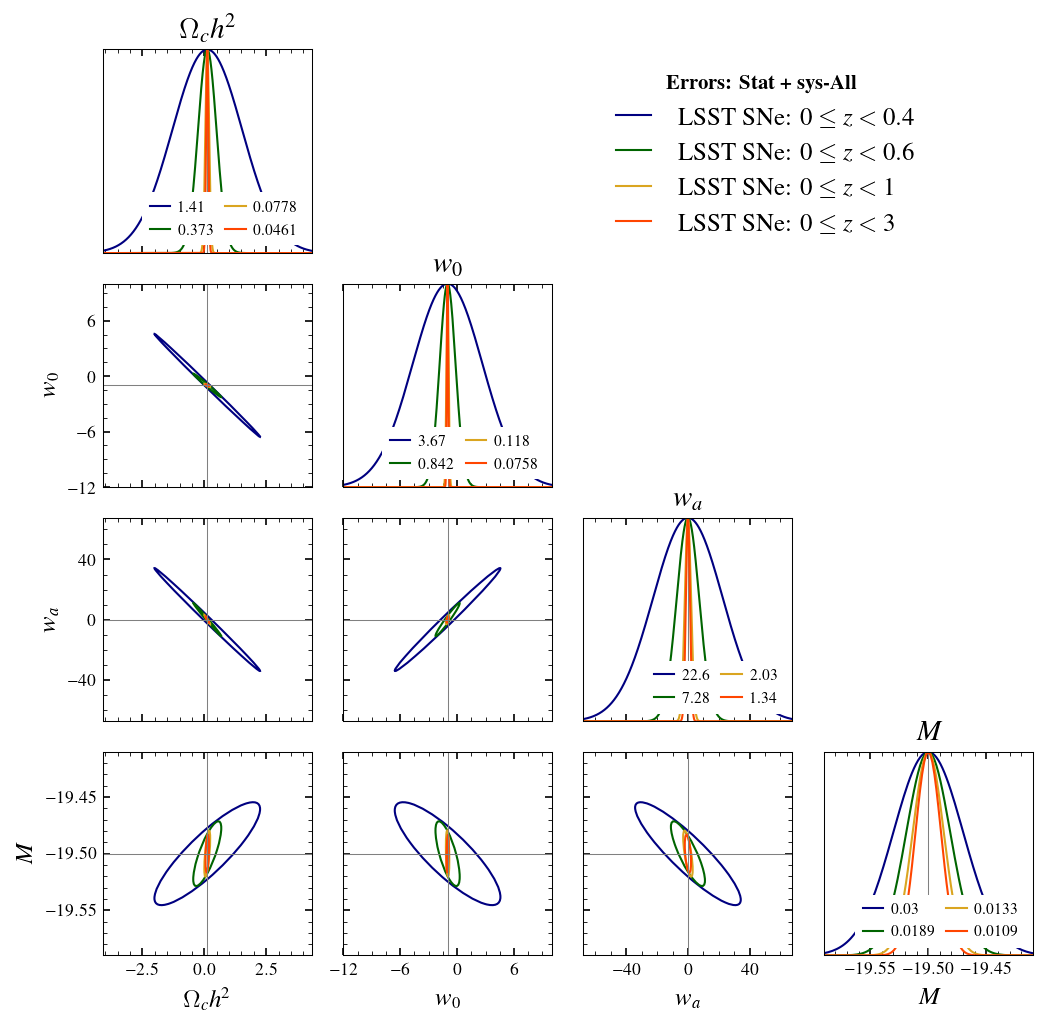

In [18]:
#make plot
if which_sne_data == 'lsst_binned':
    sne_exp_lab = 'LSST'
elif which_sne_data == 'lsst_unbinned':
    sne_exp_lab = 'LSST-unbinned'
elif which_sne_data == 'des':
    sne_exp_lab = 'DES'
#desired_params_to_plot = ['h', 'omch2', 'ws', 'wa']
desired_params_to_plot = sne_params
zlabel_dic = {}
for ziter in sne_z_bin_dic:
    zlabel_dic[ziter] = r'%s SNe: $%g \le z < %g$' %(sne_exp_lab, sne_z_bin_dic[ziter][0], sne_z_bin_dic[ziter][1])
    '''
    if maxz_dic[ziter] > 1.5:
        zlabel_dic[maxz_iter] = r'%s SNe: All' %(sne_exp_lab)
    '''
print(zlabel_dic)
color_dic = {0: 'navy', 1: 'darkgreen', 2: 'goldenrod', 3: 'orangered', 4: 'black'}
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

reqd_sne_cov_tag = 0 ##8 ##0 ##8
clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
for curr_sne_cov_tag in sne_cov_tag_dic:
    if curr_sne_cov_tag != reqd_sne_cov_tag: continue
    parent_fisher_dic = master_fisher_dic[curr_sne_cov_tag]
    ##print(parent_fisher_dic.keys()); sys.exit()
    ##color_dic = {0: 'black'}
    ##print( parent_fisher_dic )
    color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic, tr, tc, sne_params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for ziter in zlabel_dic:
    plot([], [], color = color_dic[ziter], label = r'%s' %(zlabel_dic[ziter]))

legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
axis('off')

'''
#save thr Fisher matrix
opfname = 'data/lsst_SNe/fisher_sne_tmp.npy'
op_dic = {}
op_dic['fisher'] = master_fisher_dic
op_dic['param_dict'] = param_dict
op_dic['params'] = params
print(params)
np.save( opfname, op_dic )
'''

# Transformed fisher for omega_m

In [43]:
if transform_fisher:
    fix_params_arr = ['h', 'M']
    mod_param_arr = [['omch2', 'omega_m']]
    param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
    desired_params_to_plot = ['omega_m', 'ws', 'wa']


    reqd_sne_cov_tag = 0 ##8 ##0 ##8
    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    for curr_sne_cov_tag in sne_cov_tag_dic:
        if curr_sne_cov_tag != reqd_sne_cov_tag: continue
        print(curr_sne_cov_tag)
        parent_fisher_dic = master_fisher_dic[curr_sne_cov_tag]

        #rotate Fisher matrix now
        parent_fisher_dic_mod, param_names_mod = misc.rotate_fisher_mat_parent(parent_fisher_dic, sne_params, param_dict, mod_param_arr, fix_params_arr = fix_params_arr)
        ###sys.exit()

        color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic_mod, tr, tc, param_names_mod, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    #legend
    if len(desired_params_to_plot)>=3:
        ax = subplot(tr, tc, 3)
    elif len(desired_params_to_plot)==2:
        ax = subplot(tr, tc, 2)
    else:
        ax = subplot(tr, tc, 1)
    for liter in zlabel_dic:
        print(liter)
        plot([], [], color = color_dic[liter], label = r'%s' %(zlabel_dic[liter]))

    legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
    axis('off')

# Fisher bias

Reading and process details for which_sne_data = lsst_binned
	Cov inv file = data/lsst_SNe//sne_lsst_binned_cov_inv.npy. Exists = True
		getting the covariance and cov inv for tag = 0 (Stat + sys-All)
		getting the covariance and cov inv for tag = 1 (Stat-only)
		getting the covariance and cov inv for tag = 2 (Stat + sys-ZSHIFT)
		getting the covariance and cov inv for tag = 3 (Stat + sys-ZERRSCALE)
		getting the covariance and cov inv for tag = 4 (Stat + sys-Photo_shift)
		getting the covariance and cov inv for tag = 5 (Stat + sys-MWEBV)
		getting the covariance and cov inv for tag = 6 (Stat + sys-Cal_ZP)
		getting the covariance and cov inv for tag = 7 (Stat + sys-Cal_wave)
		getting the covariance and cov inv for tag = 8 (Stat + sys-Cal)
SNe cov tag = 0
omch2 0.12 0.12
ws -1 -1.0
wa 0 0.0
M -19.5 -19.5
omch2 0.12 0.07529284969447303
ws -1 -0.894958547898284
wa 0 0.859552094531864
M -19.5 -19.49677290271214


<Figure size 900x600 with 0 Axes>

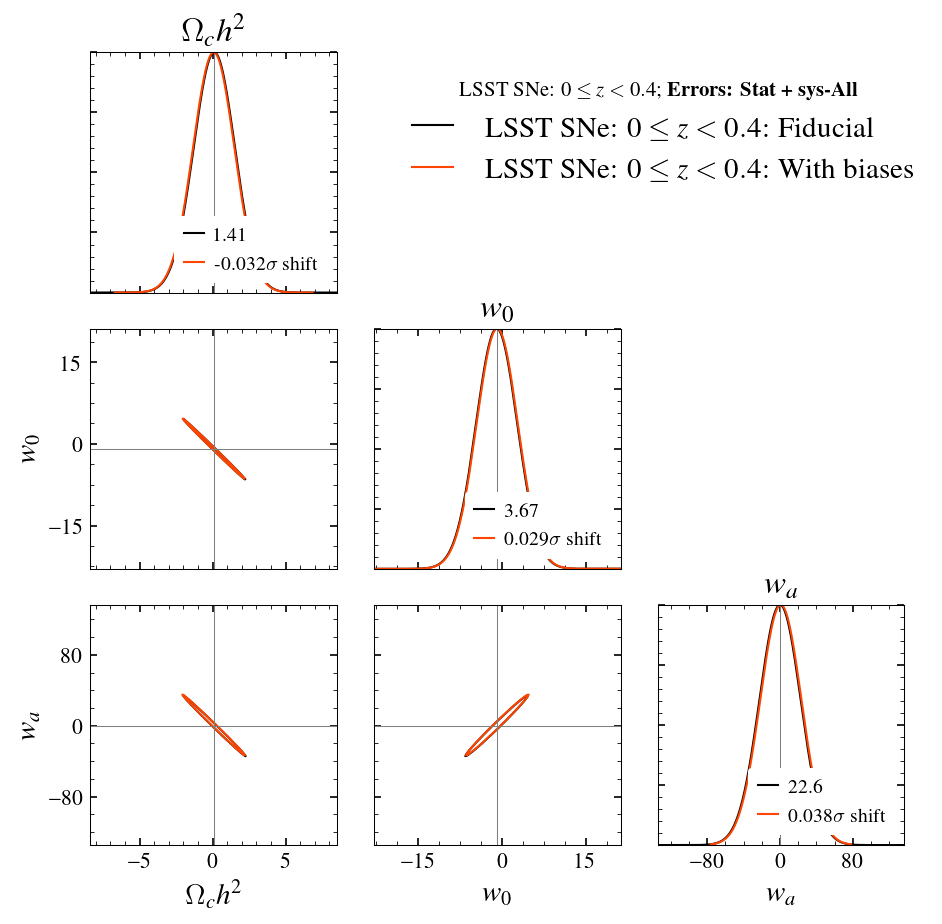

SNe cov tag = 1
SNe cov tag = 2
SNe cov tag = 3
SNe cov tag = 4
SNe cov tag = 5
SNe cov tag = 6
SNe cov tag = 7
SNe cov tag = 8


In [126]:
import copy
if (0): #plot sys errors
    plot(sne_zarr, sne_muarr, 'r.')
    plot(sne_zarr, sne_muarr - sne_muerr_sys, 'k.'); show()
    sys.exit()

reqd_sne_cov_tag = 0 ##8 ##0
reqd_ziter = 0 ##1 #3
if which_sne_data == 'des':
    reqd_sne_cov_tag = 0
    reqd_ziter = 0
    
sne_details_dic = sne_cmb_fisher_tools.get_sne_details(which_sne_data, unbinned_sne_sim_no = unbinned_sne_sim_no, obtain_covs = True)
sne_zarr = sne_details_dic['sne_zarr']
sne_muarr = sne_details_dic['sne_muarr']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_muerr_sys = sne_details_dic['sne_muerr_sys']
sne_muerr_stat = sne_details_dic['sne_muerr_stat']
sne_stretch_x1_arr = sne_details_dic['sne_stretch_x1']
sne_color_c_arr = sne_details_dic['sne_color_c']
sne_z_bin_dic = sne_details_dic['sne_z_bin_dic']
sne_params = sne_details_dic['sne_params']
sne_sys_cov_dic = sne_details_dic['sne_sys_cov_dic']
sne_stat_cov = sne_details_dic['sne_stat_cov']
sne_tot_cov_dic = sne_details_dic['sne_tot_cov_dic']
sne_tot_cov_inv_dic = sne_details_dic['sne_tot_cov_inv_dic']
sne_cov_tag_dic = sne_details_dic['sne_cov_tag_dic']

master_fisher_bias_dic = {}
for curr_sne_cov_tag in sne_cov_tag_dic:
    print('SNe cov tag = %s' %(curr_sne_cov_tag))

    master_fisher_bias_dic[curr_sne_cov_tag] = {}
    for ziter in range(len(sne_z_bin_dic)):
        
        #perform selection for the current z-bin
        zinds = np.where( (sne_zarr>sne_z_bin_dic[ziter][0]) & (sne_zarr<=sne_z_bin_dic[ziter][1]) )[0]
        curr_sne_zarr = sne_zarr[zinds]
        curr_sne_muarr = sne_muarr[zinds]        
        
        ##curr_sne_muerr_sys = sne_muerr_sys[zinds]
        curr_sne_sys_cov = sne_sys_cov_dic[curr_sne_cov_tag][zinds[:, None], zinds[None, :]]
        curr_sne_muerr_sys = np.diag(curr_sne_sys_cov)**0.5

        curr_sne_cov, curr_sne_cov_inv = None, None
        curr_sne_stat_cov = sne_stat_cov[zinds[:, None], zinds[None, :]]
        if sne_tot_cov_dic is not None:
            curr_sne_cov = np.copy(sne_tot_cov_dic[curr_sne_cov_tag])
            curr_sne_cov = curr_sne_cov[zinds[:, None], zinds[None, :]]
        if sne_tot_cov_inv_dic is not None:
            curr_sne_cov_inv = np.copy(sne_tot_cov_inv_dic[curr_sne_cov_tag])
            curr_sne_cov_inv = curr_sne_cov_inv[zinds[:, None], zinds[None, :]]

            
        #get distance modules derivatives w.r.t cosmo params
        if 'omch2' in sne_params:
            use_hsq_units = True
        elif 'omega_m' in sne_params:
            use_hsq_units = False
        distance_modulus_deriv_dict = sne_cmb_fisher_tools.get_distance_modulus_derivatives(curr_sne_zarr, param_dict, sne_params, baselinecosmo = baselinecosmo, use_hsq_units = use_hsq_units)

        #get Fisher
        lsst_dm_sne_fisher_mat = sne_cmb_fisher_tools.get_sne_distance_modulus_fisher(sne_params, curr_sne_cov, curr_sne_zarr, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
    
        #get Fisher bias
        #final_bias_vector = sne_cmb_fisher_tools.get_bias_vector(lsst_dm_sne_fisher_mat, sne_params, curr_sne_zarr, curr_sne_stat_cov, curr_sne_muarr, curr_sne_muerr_sys, distance_modulus_deriv_dict)
        final_bias_vector = sne_cmb_fisher_tools.get_bias_vector(lsst_dm_sne_fisher_mat, sne_params, curr_sne_zarr, curr_sne_cov, curr_sne_muarr, curr_sne_muerr_sys, distance_modulus_deriv_dict, cov_inv = curr_sne_cov_inv)
        ###print( final_bias_vector )
        ##print( final_bias_vector ); sys.exit()
        master_fisher_bias_dic[curr_sne_cov_tag][ziter] = [sne_params, lsst_dm_sne_fisher_mat, final_bias_vector]
        

        if curr_sne_cov_tag == reqd_sne_cov_tag and ziter == reqd_ziter: #show plot
            clf()
            tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
            figure(figsize = (tr+4, tc+4))
            subplots_adjust(hspace=0.15, wspace = 0.15)
            color_arr = ['black', 'orangered']
            zlabelval = r'%s SNe: $%g \le z < %g$' %(sne_exp_lab, sne_z_bin_dic[ziter][0], sne_z_bin_dic[ziter][1])
            itername_arr = [r'%s: Fiducial' %(zlabelval), r'%s: With biases' %(zlabelval)]
            sne_exp_lab = r'LSST'

            for pliter in range(2): 
                bias_dic = None
                param_dict_mod = copy.deepcopy( param_dict )
                if pliter == 0:
                    itername = itername_arr[pliter]
                    curr_final_bias_vector = np.zeros_like(final_bias_vector)        
                else:
                    itername = itername_arr[pliter]
                    curr_final_bias_vector = np.copy(final_bias_vector)

                ##print(curr_final_bias_vector); sys.exit()
                for pind, p in enumerate( sne_params ):
                    fid_val = param_dict_mod[p]
                    mod_val = fid_val + curr_final_bias_vector[pind]
                    print(p, fid_val, mod_val)
                    param_dict_mod[p] = mod_val
                ##sys.exit()

                if pliter == 1:
                    bias_dic = {}
                    for pind, p in enumerate( sne_params ):
                        shifted_val = param_dict[p] - curr_final_bias_vector[pind]
                        bias_dic[p] = [shifted_val, curr_final_bias_vector[pind]]


                F_dic = {}
                F_dic[itername] = lsst_dm_sne_fisher_mat

                color_dic = {}
                color_dic[itername] = color_arr[pliter]

                fix_axis_range_to_xxsigma = 6.
                if pliter == 0:
                    mark_fid_lines = True
                else:
                    mark_fid_lines = False
                color_dic, ls_dic = misc.make_triangle_plot(F_dic, tr, tc, sne_params, param_dict_mod, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, bias_dic = bias_dic, ncol = 1, mark_fid_lines = mark_fid_lines)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

            #legend
            if len(desired_params_to_plot)>3:
                ax = subplot(tr, tc, 2)
            elif len(desired_params_to_plot)==3:
                ax = subplot(tr, tc, 2)
            elif len(desired_params_to_plot)==2:
                ax = subplot(tr, tc, 2)
            else:
                ax = subplot(tr, tc, 1)

            for pliter in range(2):
                plot([], [], color = color_arr[pliter], label = r'%s' %(itername_arr[pliter]))

            legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'%s; {\bf Errors: %s}' %(zlabelval, sne_cov_tag_dic[reqd_sne_cov_tag]))
            axis('off')            
            show(); ##sys.exit()


In [119]:
final_bias_vector

array([-0.01273409,  0.03480327,  0.28421737,  0.006388  ])

omch2 -0.1482429018331618 -0.19295005213868877
ws -0.369751287389704 -0.26470983528798797
wa 5.157312567191184 6.016864661723048
M -19.48063741627285 -19.47741031898499
omch2 1 0.4015
ws 1 0.7799
wa 1 0.30800000000000005


<Figure size 900x600 with 0 Axes>

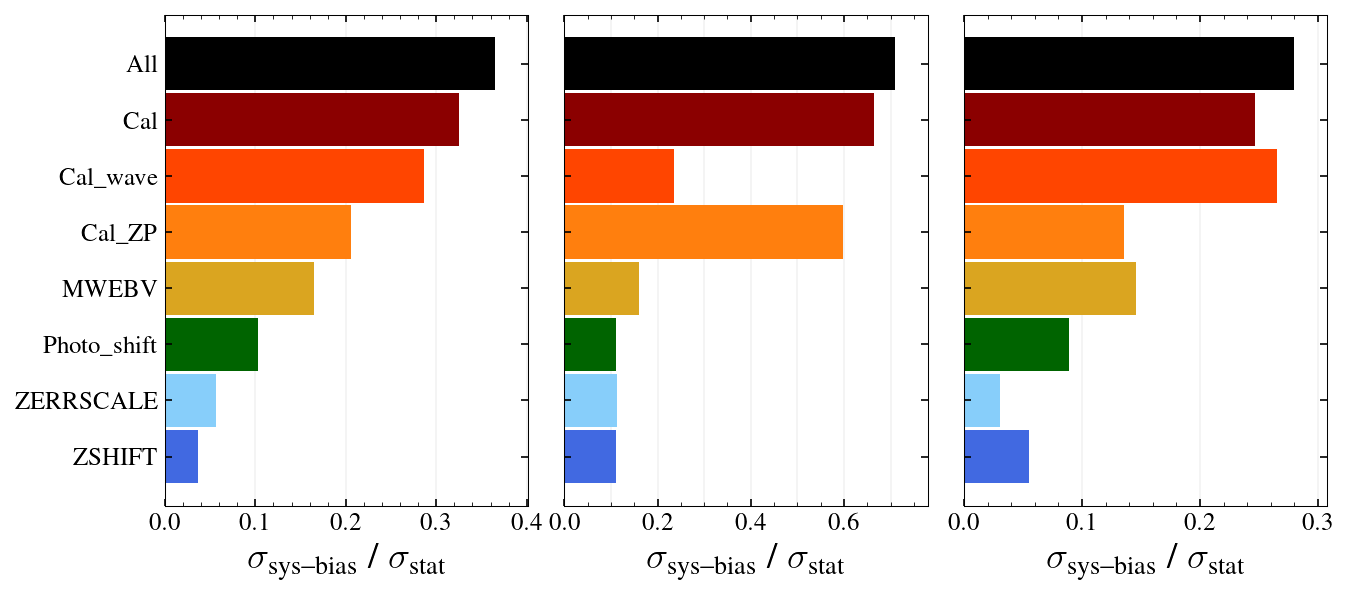

SystemExit: 

In [132]:
ind_params_for_bar_plot = ['omch2', 'ws', 'wa']
fix_params_arr_for_ind_params = None

reqd_z_bin = 3

bias_dic_to_plot = {}
for curr_sne_cov_tag in master_fisher_bias_dic:
    bias_dic_to_plot[curr_sne_cov_tag] = {}
    for curr_ziter in master_fisher_bias_dic[curr_cov_tag]:
        curr_params, curr_F_mat, curr_bias_vector = master_fisher_bias_dic[curr_sne_cov_tag][reqd_z_bin]
        curr_sigma_dic = misc.get_sigma_of_a_parameter(curr_F_mat, curr_params, ind_params_for_sigma_calc, fix_params_arr = fix_params_arr_for_ind_params)
        curr_bias_dic = {}
        for (p, b) in zip( curr_params, curr_bias_vector):
            curr_bias_dic[p] = b
        bias_dic_to_plot[curr_sne_cov_tag][curr_ziter] = [curr_sigma_dic, curr_bias_dic]

    ##print( curr_sne_cov_tag, curr_bias_dic )
##sys.exit()

for pind, p in enumerate( sne_params ):
    fid_val = param_dict_mod[p]
    mod_val = fid_val + curr_final_bias_vector[pind]
    print(p, fid_val, mod_val)
    param_dict_mod[p] = mod_val

clf()
fsval = 14
rspan_1, rspan_2, rspan_gap = 2, 8, 1
tr, tc = rspan_1+rspan_2+rspan_gap, len( ind_params_for_bar_plot )
figure(figsize = (10, 6.))
subplots_adjust(wspace = 0.1, hspace = 0.25)
for pcntr, ppp in enumerate( ind_params_for_bar_plot ):

    ax = subplot2grid((tr, tc), (rowval, pcntr), rowspan = rspan)
    color_dict = {0: 'black', 1: 'tab:green', 2: 'royalblue', 3: 'lightskyblue', 
                  4: 'darkgreen', 5: 'goldenrod', 
                 6: 'tab:orange', 7: 'orangered', 8: 'darkred'}

    #fiducial
    fid_sne_cov_tag = 1 #stat-only
    fid_sigma_val = bias_dic_to_plot[fid_sne_cov_tag][reqd_z_bin][0][ppp]
    fid_param_val = param_dict_mod[ppp]

    #reqd_sne_cov_tag = list( sigma_dic.keys() )
    reqd_sne_cov_tag = [2,3,4,5,6,7,8,0]
    #reqd_sne_cov_tag.remove( fid_sne_cov_tag )

    #plot sigma for different cov cases
    xmaxval = 0.
    ytick_label_arr = []
    yloc = 0
    #reqd_sne_cov_tag = list( bias_dic_to_plot.keys() )
    for cntr, curr_sne_cov_tag in enumerate( reqd_sne_cov_tag ):
        if curr_sne_cov_tag not in reqd_sne_cov_tag: continue
        if curr_sne_cov_tag == 1: continue #remove no-sys
                
        curr_sigma_val = bias_dic_to_plot[curr_sne_cov_tag][reqd_z_bin][0][ppp]
        curr_bias_val = bias_dic_to_plot[curr_sne_cov_tag][reqd_z_bin][1][ppp]
        ##print( ppp, curr_sne_cov_tag, curr_bias_val )
        #curr_param_val = param_dict_mod[ppp]


        curr_val = abs(curr_bias_val / fid_sigma_val)
        ##curr_val = abs(curr_bias_val / curr_sigma_val)
        barh( yloc, curr_val, height = 0.95, color = color_dict[curr_sne_cov_tag])
        if (0):##pliter == 0: 
            text(
                0., yloc*0.9, '%g' %(curr_val),
                va='center',
                ha='left',  # Left-align the text
                fontsize=fsval-2,  # Using the given fontsize for bar text
                color='black',  # White color makes the text more readable on colored bars                    
                bbox=dict(edgecolor = 'None', facecolor='white', boxstyle='round,pad=0.1')
            )
        xmaxval = max( xmaxval, curr_val )
        tmpsplit = sne_cov_tag_dic[curr_sne_cov_tag].split('+')
        if len(tmpsplit) == 1:
            curr_ylab = r'No sys'
        else:
            curr_ylab = tmpsplit[1].replace('_', '\_').replace('sys-', '')
        ytick_label_arr.append( curr_ylab )
        yloc += 1

    xmaxval = round(xmaxval, 3) * 1.1
    print(ppp, pliter, xmaxval)
    xlim(0., xmaxval)
    
    if (1): #draw grids
        ##grid(True, which = 'major', axis = 'x', lw = 0.2, zorder = -100, alpha = 0.2)
        tmpxarr_for_gridlines = np.arange( 0., xmaxval, 0.1)
        for gl in tmpxarr_for_gridlines:
            axvline( gl, lw = 0.2, zorder = -100., alpha = 0.2)
        
    
    ax = misc.format_axis(ax, fsval-2, fsval-2)

    if pliter == 0:
        title(r'%s' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 6)
    
    #ax.set_yticklabels(ytick_label_arr)
    yticks(np.arange(len(ytick_label_arr)), ytick_label_arr)
    #ax.yaxis.set_major_locator(plt.MaxNLocator(len(ytick_label_arr)))
    if pcntr != 0:
        setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='y', which='minor', length=0)
    xlabel(r'$\sigma_{\rm sys-bias}$ / $\sigma_{\rm stat}$', fontsize = fsval + 4)
    ##axvspan(0., 1, alpha = 0.3, color = 'gray', zorder = -100)

#plname = 'plots/sne_constraints_stat_plus_sys.pdf'
#savefig( plname, dpi = 200.)
show(); sys.exit()
        
    
      

In [92]:
sne_cov_tag_dic[curr_sne_cov_tag]

'Stat-only'

(4, 4)
(4, 4)
(3, 3)
dict_keys([0, 1, 2])
0
1
2


<Figure size 900x600 with 0 Axes>

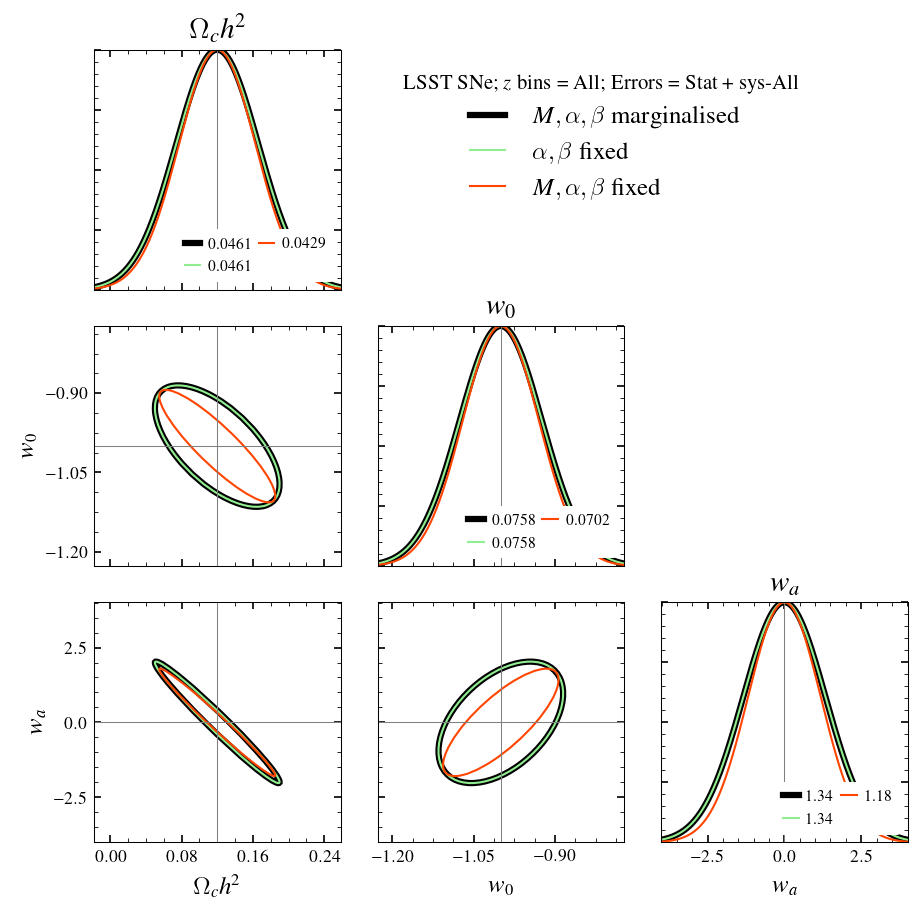

In [46]:
# Fixed vs marginalised M

sne_exp_lab = 'LSST'
zlabval = r'%s SNe; $z$ bins = All' %(sne_exp_lab)
color_dic = {0: 'black', 1: 'lightgreen', 2: 'orangered'}
lw_dic = {0: 3., 1: 1., 2: 1.}
labval_dic = {0: r'$M, \alpha, \beta$ marginalised', 1: r'$\alpha, \beta$ fixed', 2: r'$M, \alpha, \beta$ fixed'}
fix_axis_range_to_xxsigma = 3 ##10 ##None #3
fsval = 12
reqd_sne_cov_tag = 0 ##8 ##0 ##8
reqd_z_iter = 3
fisher_dic_to_plot = {}
for tmpiter in range(3):

    desired_params_to_plot = ['omch2', 'ws', 'wa']
    curr_F_mat = np.copy( master_fisher_dic[reqd_sne_cov_tag][reqd_z_iter] )
    
    if tmpiter == 1:
        curr_F_mat, curr_mod_params = misc.fix_params(np.copy(curr_F_mat), np.copy(sne_params), ['alpha', 'beta'])
    elif tmpiter == 2:
        curr_F_mat, curr_mod_params = misc.fix_params(np.copy(curr_F_mat), np.copy(sne_params), ['M', 'alpha', 'beta'])
    print(curr_F_mat.shape)
    
    fisher_dic_to_plot[tmpiter] = curr_F_mat
    
print( fisher_dic_to_plot.keys() )
           

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_dic_to_plot, tr, tc, sne_params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, lw_dic = lw_dic)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 2)
for liter in labval_dic:
    print(liter)
    plot([], [], color = color_dic[liter], label = r'%s' %(labval_dic[liter]), lw = lw_dic[liter])

legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'%s; Errors = %s' %(zlabval, sne_cov_tag_dic[reqd_sne_cov_tag]))
axis('off')
show()

# Whisker plots for individual parameters

omch2 0 0.050600000000000006
ws 0 0.08360000000000001
wa 0 1.4718000000000002
M 0 0.0121
omch2 1 1.2958
ws 1 1.5939
wa 1 1.2793
M 1 1.3475000000000001


<Figure size 900x600 with 0 Axes>

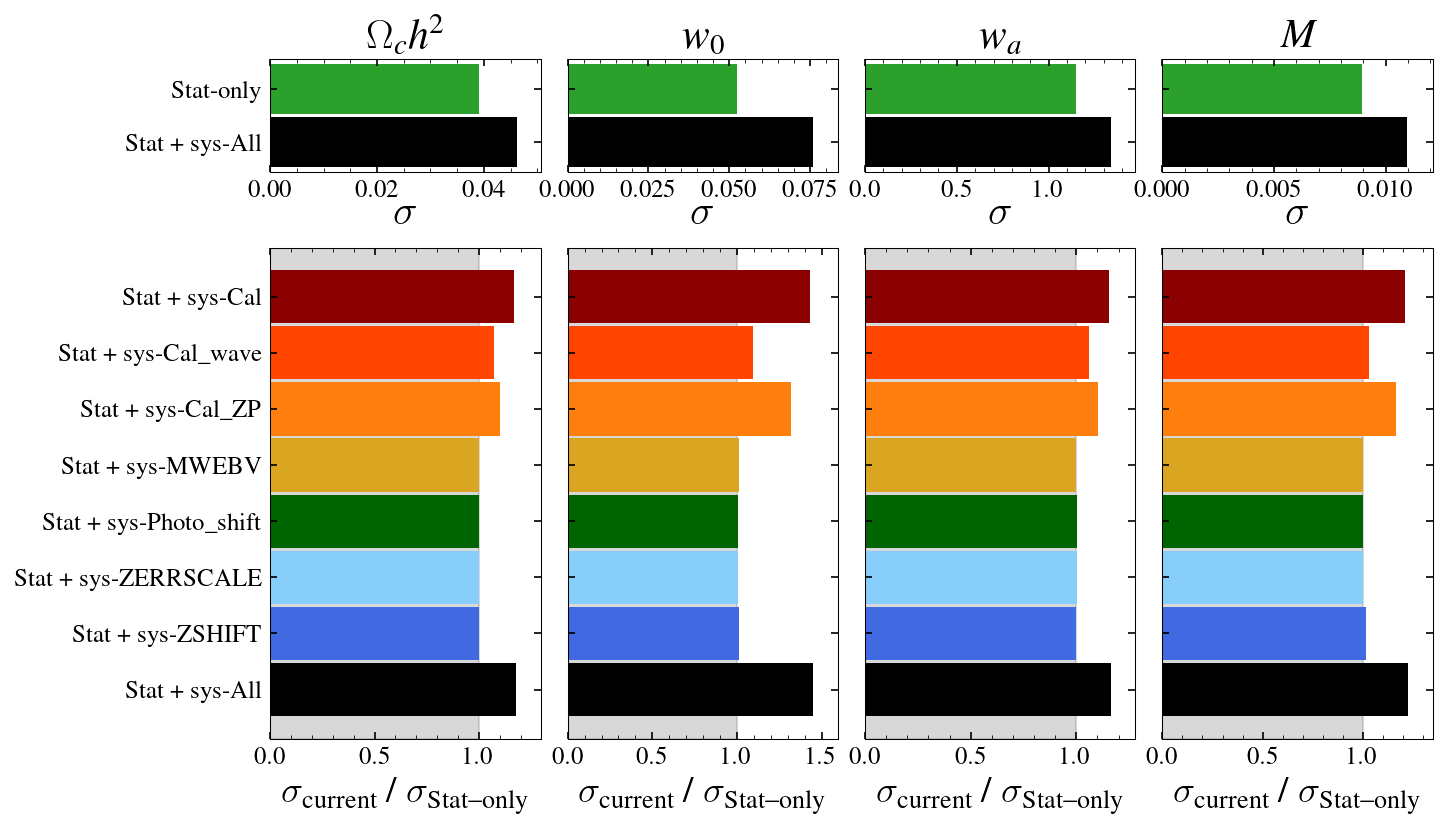

SystemExit: 

In [48]:
reqd_z_bin = 3
if (0):
    ind_params_for_sigma_calc = ['omch2', 'ws', 'wa'] ###np.copy(sne_params)
    fix_params_arr_for_ind_params = ['M']
if (1):
    ind_params_for_sigma_calc = np.copy(sne_params)
    fix_params_arr_for_ind_params = None

sigma_dic = {}
for curr_sne_cov_tag in sne_cov_tag_dic:
    curr_F_mat = master_fisher_dic[curr_sne_cov_tag][reqd_z_bin]
    curr_sigma_dic = misc.get_sigma_of_a_parameter(curr_F_mat, sne_params, ind_params_for_sigma_calc, fix_params_arr = fix_params_arr_for_ind_params)
    ###print( curr_sne_cov_tag, curr_sigma_dic )
    sigma_dic[curr_sne_cov_tag] = curr_sigma_dic

    
clf()
fsval = 14
rspan_1, rspan_2, rspan_gap = 2, 8, 1
tr, tc = rspan_1+rspan_2+rspan_gap, len( ind_params_for_sigma_calc )
figure(figsize = (10, 6.))
subplots_adjust(wspace = 0.1, hspace = 0.25)
for pliter in range(2):

    if pliter == 0:
        rspan = rspan_1
        rowval = 0
    else:
        rspan = rspan_2
        rowval = rspan_1+rspan_gap
    
    for pcntr, ppp in enumerate( ind_params_for_sigma_calc ):


        ax = subplot2grid((tr, tc), (rowval, pcntr), rowspan = rspan)
        color_dict = {0: 'black', 1: 'tab:green', 2: 'royalblue', 3: 'lightskyblue', 
                      4: 'darkgreen', 5: 'goldenrod', 
                     6: 'tab:orange', 7: 'orangered', 8: 'darkred'}

        if pliter == 0:
            reqd_sne_cov_tag = [0, 1]
        else:
            fid_sne_cov_tag = 1 #stat-only
            fid_sigma_val = sigma_dic[fid_sne_cov_tag][ppp]
            reqd_sne_cov_tag = list( sigma_dic.keys() )
            reqd_sne_cov_tag.remove( fid_sne_cov_tag )
            #reqd_sne_cov_tag = [1, 8, 6, 7, 5, 4, 3, 2]

        #plot sigma for different cov cases
        xmaxval = 0.
        ytick_label_arr = []
        yloc = 0
        for cntr, curr_sne_cov_tag in enumerate( reqd_sne_cov_tag ):
            if curr_sne_cov_tag not in reqd_sne_cov_tag: continue
                    
            curr_sigma_val = sigma_dic[curr_sne_cov_tag][ppp]
            if pliter == 0:
                curr_val = curr_sigma_val                
            else:
                curr_val = curr_sigma_val / fid_sigma_val
                ##print( curr_val ); sys.exit()
            barh( yloc, curr_val, height = 0.95, color = color_dict[curr_sne_cov_tag])
            if (0):##pliter == 0: 
                text(
                    0., yloc*0.9, '%g' %(curr_val),
                    va='center',
                    ha='left',  # Left-align the text
                    fontsize=fsval-2,  # Using the given fontsize for bar text
                    color='black',  # White color makes the text more readable on colored bars                    
                    bbox=dict(edgecolor = 'None', facecolor='white', boxstyle='round,pad=0.1')
                )
            xmaxval = max( xmaxval, curr_val )
            ytick_label_arr.append( sne_cov_tag_dic[curr_sne_cov_tag].replace('_', '\_') )
            yloc += 1

        xmaxval = round(xmaxval, 3) * 1.1
        print(ppp, pliter, xmaxval)
        xlim(0., xmaxval)
        
        ax = misc.format_axis(ax, fsval-2, fsval-2)

        if pliter == 0:
            title(r'%s' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 6)
        
        #ax.set_yticklabels(ytick_label_arr)
        yticks(np.arange(len(ytick_label_arr)), ytick_label_arr)
        #ax.yaxis.set_major_locator(plt.MaxNLocator(len(ytick_label_arr)))
        if pcntr != 0:
            setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(axis='y', which='minor', length=0)
        if pliter == 0:
            #xlabel(r'$\sigma$(%s)' %(misc.get_latex_param_str(ppp)), fontsize = fsval + 4)
            xlabel(r'$\sigma$', fontsize = fsval + 6, labelpad = -3)
        else:
            xlabel(r'$\sigma_{\rm current}$ / $\sigma_{\rm Stat-only}$', fontsize = fsval + 4)
            axvspan(0., 1, alpha = 0.3, color = 'gray', zorder = -100)
    
#plname = 'plots/sne_constraints_stat_plus_sys.pdf'
#savefig( plname, dpi = 200.)
show(); sys.exit()
        
    
    

# Transformed fisher for DES

In [45]:
if (1):##perform_checks_with_des:
    fix_params_arr = ['h']
    mod_param_arr = [['omch2', 'omega_m']]
    param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
    desired_params_to_plot = ['omega_m', 'ws']#, 'wa']


    reqd_sne_cov_tag = 0 ##8 ##0 ##8
    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    for curr_sne_cov_tag in sne_cov_tag_dic:
        if curr_sne_cov_tag != reqd_sne_cov_tag: continue
        print(curr_sne_cov_tag)
        parent_fisher_dic = master_fisher_dic[curr_sne_cov_tag]

        #rotate Fisher matrix now
        parent_fisher_dic_mod, param_names_mod = misc.rotate_fisher_mat_parent(parent_fisher_dic, params, param_dict, mod_param_arr, fix_params_arr = fix_params_arr)
        ###sys.exit()

        color_dic, ls_dic = misc.make_triangle_plot(parent_fisher_dic_mod, tr, tc, param_names_mod, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    #legend
    if len(desired_params_to_plot)>=3:
        ax = subplot(tr, tc, 3)
    elif len(desired_params_to_plot)==2:
        ax = subplot(tr, tc, 2)
    else:
        ax = subplot(tr, tc, 1)
    for liter in zlabel_dic:
        print(liter)
        plot([], [], color = color_dic[liter], label = r'%s' %(zlabel_dic[liter]))

    legend(loc = 2, fontsize = fsval, framealpha = 0., title = r'{\bf Errors: %s}' %(sne_cov_tag_dic[reqd_sne_cov_tag]))
    axis('off')

0


KeyError: 0

<Figure size 900x600 with 0 Axes>

<Figure size 900x900 with 0 Axes>

omch2 0 0.0473
ws 0 0.07700000000000001
wa 0 1.3013000000000001
omch2 1 1.6335000000000002
ws 1 1.4839
wa 1 1.7039


<Figure size 900x600 with 0 Axes>

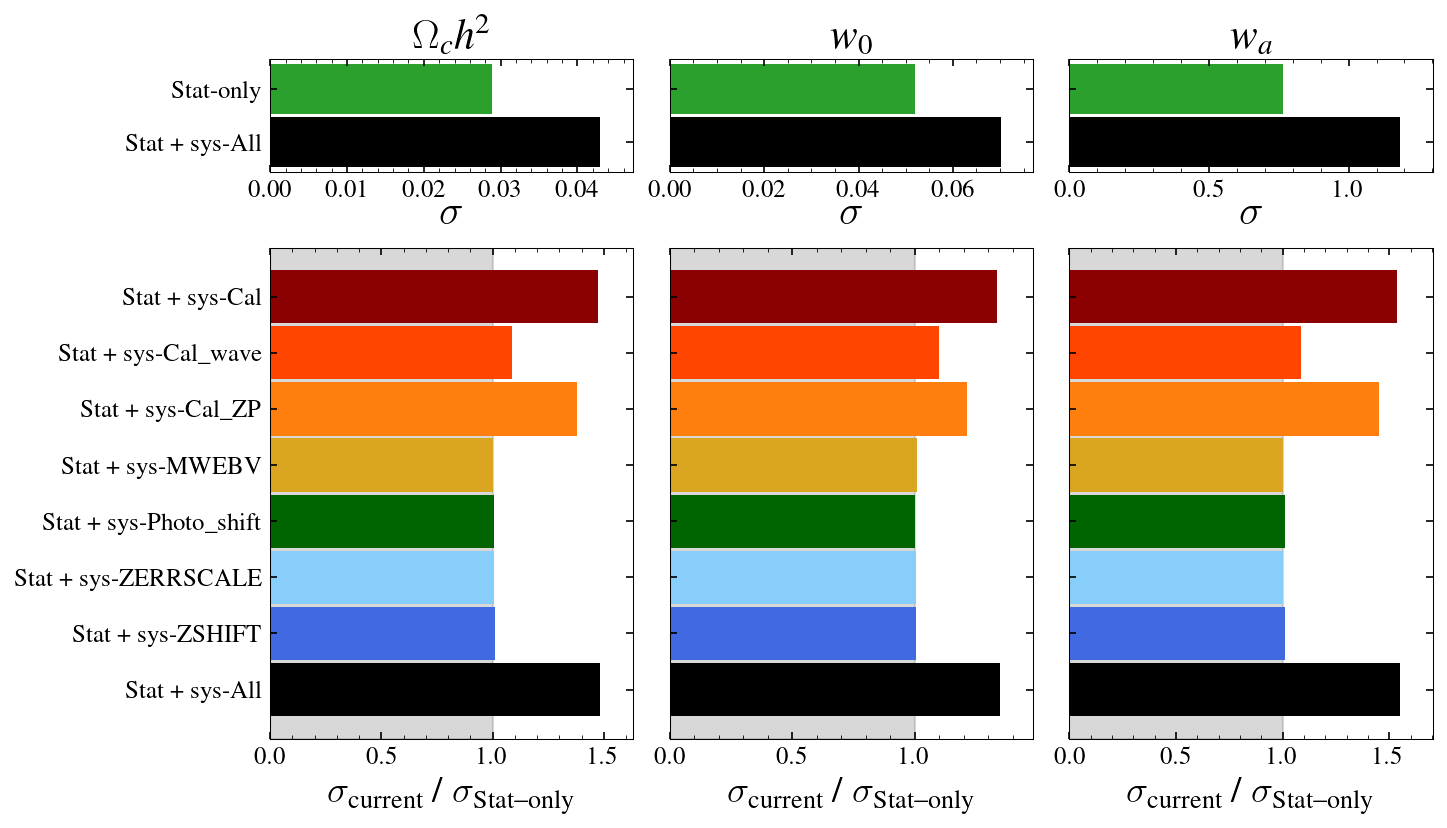

SystemExit: 

/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3449: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [45]:
ax.set_yticklabels

In [105]:
'''
#make plot
desired_params_to_plot = ['h', 'omch2', 'w0', 'wa']
fisher_dic = {'LSST': lsst_dm_sne_fisher_mat}
color_dic = {'LSST': 'black'}
fix_axis_range_to_xxsigma = 3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_dic, tr, tc, params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)
'''

"\n#make plot\ndesired_params_to_plot = ['h', 'omch2', 'w0', 'wa']\nfisher_dic = {'LSST': lsst_dm_sne_fisher_mat}\ncolor_dic = {'LSST': 'black'}\nfix_axis_range_to_xxsigma = 3\nfsval = 12\n\nclf()\ntr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )\nfigure(figsize = (tr+4, tc+4))\nsubplots_adjust(hspace=0.15, wspace = 0.15)\ncolor_dic, ls_dic = misc.make_triangle_plot(fisher_dic, tr, tc, params, param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)\n"

In [ ]:
if (0): #external CMB fisher
    sobaseline_fisher_fname = 'data/cmb_fisher/SO/sobaseline_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_0.4fsky_300minlt_3500maxlt_300minlp_4000maxlp_TT-EE-TE-PP_MVlensingest_galaxy0_galmask-1_pluslensing_Alens-Aphiphi-As-h-mnu-neff-nrun-ns-ombh2-omch2-omk-tau-ws-13cosmo.npy'
    sogoal_fisher_fname = 'data/cmb_fisher/SO/sogoal_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_0.4fsky_300minlt_3500maxlt_300minlp_4000maxlp_TT-EE-TE-PP_MVlensingest_galaxy0_galmask-1_pluslensing_Alens-Aphiphi-As-h-mnu-neff-nrun-ns-ombh2-omch2-omk-tau-ws-13cosmo.npy'

    sobaseline_fisher_dic = np.load(sobaseline_fisher_fname, allow_pickle=True).item()
    sogoal_fisher_dic = np.load(sogoal_fisher_fname, allow_pickle=True).item()

    sobaseline_fisher_params = sobaseline_fisher_dic['param_names']
    sobaseline_fisher_F_mat = sobaseline_fisher_dic['F_mat']

    sogoal_fisher_params = sogoal_fisher_dic['param_names']
    sogoal_fisher_F_mat = sogoal_fisher_dic['F_mat']

    #fix params
    ##fix_param_arr = ['Alens', 'Aphiphi', 'mnu', 'neff', 'nrun', 'ns', 'ombh2', 'tau', 'As', 'omk']
    fix_param_arr = ['Alens', 'Aphiphi', 'mnu', 'neff', 'nrun', 'omk']
    sobaseline_fisher_F_mat, sobaseline_fisher_params = misc.fix_params(sobaseline_fisher_F_mat, sobaseline_fisher_params, fix_param_arr)
    sogoal_fisher_F_mat, sogoal_fisher_params = misc.fix_params(sogoal_fisher_F_mat, sogoal_fisher_params, fix_param_arr)
    
    print(sogoal_fisher_params); sys.exit()

    total_so_params = len(sogoal_fisher_params)
    
    #create a new Fisher matrix with wa. But wa will be zero for CMB
    sobaseline_fisher_F_mat_mod = np.zeros_like((total_so_params+1, total_so_params+1))
    sogoal_fisher_F_mat_mod = np.zeros_like((total_so_params+1, total_so_params+1))

    sobaseline_fisher_F_mat_mod[:3, :3] = sobaseline_fisher_F_mat
    sogoal_fisher_F_mat_mod[:3, :3] = sogoal_fisher_F_mat


    #joint: LSST + SO
    fisher_mat_sofull_lsstall = np.copy( parent_fisher_dic[maxz_key] ) + np.copy( sobaseline_fisher_F_mat_mod )

    parent_fisher_dic[maxz_key+1] = fisher_mat_sofull_lsstall


In [12]:
import astropy
from astropy import constants as const
from astropy import units as u
from astropy import coordinates as coord


cosmo = astropy.cosmology.Flatw0waCDM(H0 = param_dict['h']*100., 
                     Om0 = param_dict['omch2']/param_dict['h']**2., 
                     Ob0 = param_dict['ombh2']/param_dict['h']**2., 
                     Tcmb0 = param_dict['tcmb'], 
                     m_nu = [0., 0., param_dict['mnu']] * u.eV,
                     Neff = param_dict['neff'], 
                     w0 = param_dict['ws'], 
                     wa = param_dict['wa'], 
                     )


In [79]:
cosmo.Ode0

0.73401590965105

In [19]:
zval = 1.
5 * np.log10( cosmo.luminosity_distance(zval).value * 1e6 / 10 )

44.22881833789403

In [149]:
#param derivative and rotation stuff
params = ['As']
new_param_names = ['sigma_8']
#sne_cmb_fisher_tools.get_cosmo_derivatives_using_camb(params, new_param_names, param_dict)

camb_pars, camb_results = sne_cmb_fisher_tools.set_camb(param_dict, lmax = 1000)


In [150]:
camb_results.get_sigma8_0()


0.8105536759783709